# Exploratory Data Analysis — SQuAD 2.0

This notebook covers the full EDA pipeline: description of the original SQuAD 2.0 dataset, stratified sampling into train/val/test splits, and in-depth analysis of the training set.

## 1. Setup and Data Preparation

### 1.1 Imports and Enviorment Setup

In [659]:
import json
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
nltk.download('stopwords', quiet=True)

import spacy
from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

STOP = set(stopwords.words('english'))
TOKEN_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
WH_WORDS = ['what', 'who', 'when', 'where', 'why', 'how', 'which']

# Load spaCy model (used for NER, POS, dependency parsing)
nlp = spacy.load('en_core_web_sm')

# Reusable styled table function — use for all previews in this notebook
def show_table(df, caption='', n=5):
    return (
        df.head(n)
        .style
        .set_caption(caption)
        .hide(axis='index')
        .set_properties(**{
            'text-align': 'left',
            'padding': '6px 14px',
            'font-size': '13px',
        })
        .set_table_styles([
            {'selector': 'thead th', 'props': [
                ('font-weight', 'bold'),
                ('font-size', '13px'),
                ('padding', '8px 14px'),
                ('border-bottom', '2px solid #555'),
            ]},
            {'selector': 'caption', 'props': [
                ('font-size', '13px'),
                ('font-weight', 'bold'),
                ('padding-bottom', '8px'),
            ]},
        ])
    )

### 1.2 Original Dataset Overview

This project explores the SQuAD 2.0 (Stanford Question Answering Dataset) task, a benchmark for extractive question answering based on Wikipedia articles. In this setting, each example consists of a context paragraph and a question. The goal of a system is to determine whether the question can be answered using the information contained in the paragraph and, if so, to extract the correct answer span directly from the text.

Unlike earlier reading comprehension datasets, SQuAD 2.0 also includes unanswerable questions, meaning that the context paragraph does not contain sufficient information to answer the question. Therefore, models must learn not only to locate relevant spans in the text but also to recognize when no valid answer is supported by the context. This makes the task substantially more challenging than standard extractive question answering benchmarks.

The objective of this project is to perform an exploratory data analysis (EDA) of the dataset in order to understand its structure, linguistic properties, and statistical characteristics before training machine learning models.

In [660]:
with open('train-v2.0.json', 'r', encoding='utf-8') as f:
    squad = json.load(f)

# Show the hierarchical JSON structure with a concrete example
article = squad['data'][0]
para    = article['paragraphs'][0]
qa      = para['qas'][0]

print('=== SQuAD 2.0 JSON Hierarchical Structure ===\n')
print(f'data  ({len(squad["data"])} articles)')
print(f'└── title: "{article["title"]}"')
print(f'    └── paragraphs  ({len(article["paragraphs"])} paragraphs in this article)')
print(f'        └── context: "{para["context"][:80]}..."')
print(f'            └── qas  ({len(para["qas"])} questions in this paragraph)')
print(f'                ├── question:      "{qa["question"]}"')
print(f'                ├── id:            "{qa["id"]}"')
print(f'                ├── is_impossible: {qa["is_impossible"]}')
if qa.get('answers'):
    print(f'                └── answers:')
    print(f'                    ├── text:         "{qa["answers"][0]["text"]}"')
    print(f'                    └── answer_start: {qa["answers"][0]["answer_start"]}')
else:
    print(f'                └── answers:      [] (empty — unanswerable)')

=== SQuAD 2.0 JSON Hierarchical Structure ===

data  (442 articles)
└── title: "Beyoncé"
    └── paragraphs  (66 paragraphs in this article)
        └── context: "Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 198..."
            └── qas  (15 questions in this paragraph)
                ├── question:      "When did Beyonce start becoming popular?"
                ├── id:            "56be85543aeaaa14008c9063"
                ├── is_impossible: False
                └── answers:
                    ├── text:         "in the late 1990s"
                    └── answer_start: 269


In [661]:
# Aggregate counts at title and context level across the full dataset
t2_contexts = defaultdict(int)
t2_qas      = defaultdict(int)

qas_per_context   = []
ans_per_context   = []
unans_per_context = []

for article in squad['data']:
    title      = article.get('title', '')
    paragraphs = article.get('paragraphs', [])
    t2_contexts[title] += len(paragraphs)

    for para in paragraphs:
        qas  = para.get('qas', [])
        n_q  = len(qas)
        n_un = sum(bool(qa.get('is_impossible', False)) for qa in qas)
        n_an = n_q - n_un
        qas_per_context.append(n_q)
        ans_per_context.append(n_an)
        unans_per_context.append(n_un)
        t2_qas[title] += n_q

titles             = list(t2_contexts.keys())
contexts_per_title = np.array([t2_contexts[t] for t in titles])
qas_per_title      = np.array([t2_qas[t] for t in titles])
qas_per_context    = np.array(qas_per_context)
ans_per_context    = np.array(ans_per_context)
unans_per_context  = np.array(unans_per_context)

total_qas   = int(qas_per_context.sum())
total_unans = int(unans_per_context.sum())
total_ans   = total_qas - total_unans

# Display counts as a styled table
display(show_table(
    pd.DataFrame([
        ('Titles',        f'{len(titles):,}'),
        ('Contexts',      f'{int(contexts_per_title.sum()):,}'),
        ('Total QAs',     f'{total_qas:,}'),
        ('Answerable',    f'{total_ans:,}  ({total_ans/total_qas:.1%})'),
        ('Unanswerable',  f'{total_unans:,}  ({total_unans/total_qas:.1%})'),
    ], columns=['Metric', 'Value']),
    caption='Counts',
    n=5
))

Metric,Value
Titles,442
Contexts,"19,035"
Total QAs,"130,319"
Answerable,"86,821 (66.6%)"
Unanswerable,"43,498 (33.4%)"


In [662]:
# Description table
desc_rows = [
    ('Total questions (QAs)',        f'{total_qas:,}'),
    ('Answerable (y=1)',             f'{total_ans:,}  ({total_ans/total_qas:.1%})'),
    ('Unanswerable (y=0)',           f'{total_unans:,}  ({total_unans/total_qas:.1%})'),
    ('Unique titles (topics)',       f'{len(titles):,}'),
    ('Unique contexts (paragraphs)', f'{int(contexts_per_title.sum()):,}'),
    ('Avg contexts per title',       f'{contexts_per_title.mean():.1f}'),
    ('Avg QAs per context',          f'{qas_per_context.mean():.1f}'),
    ('Avg QAs per title',            f'{qas_per_title.mean():.1f}'),
]

display(show_table(
    pd.DataFrame(desc_rows, columns=['Metric', 'Value']),
    caption='Dataset Description',
    n=len(desc_rows)
))

Metric,Value
Total questions (QAs),"130,319"
Answerable (y=1),"86,821 (66.6%)"
Unanswerable (y=0),"43,498 (33.4%)"
Unique titles (topics),442
Unique contexts (paragraphs),"19,035"
Avg contexts per title,43.1
Avg QAs per context,6.8
Avg QAs per title,294.8


In [663]:
# Summary statistics for key distributions in the full dataset
def summ(name, x):
    return {
        'Distribution':  name,
        'Min':           int(np.min(x)),
        'Median':        float(np.median(x)),
        'Mean':          round(float(np.mean(x)), 1),
        'P75':           float(np.percentile(x, 75)),
        'P90':           float(np.percentile(x, 90)),
        'Max':           int(np.max(x)),
    }

rows = [
    summ('Contexts per title',       contexts_per_title),
    summ('QAs per title',            qas_per_title),
    summ('QAs per context',          qas_per_context),
    summ('Answerable per context',   ans_per_context),
    summ('Unanswerable per context', unans_per_context),
]

display(show_table(
    pd.DataFrame(rows),
    caption='Distribution Summary Statistics',
    n=len(rows)
))

Distribution,Min,Median,Mean,P75,P90,Max
Contexts per title,10,37.000000,43.100000,56.000000,75.000000,149
QAs per title,36,279.000000,294.800000,351.500000,427.000000,883
QAs per context,1,5.000000,6.800000,9.000000,10.000000,30
Answerable per context,0,5.000000,4.600000,5.000000,5.000000,25
Unanswerable per context,0,0.000000,2.300000,5.000000,5.000000,15


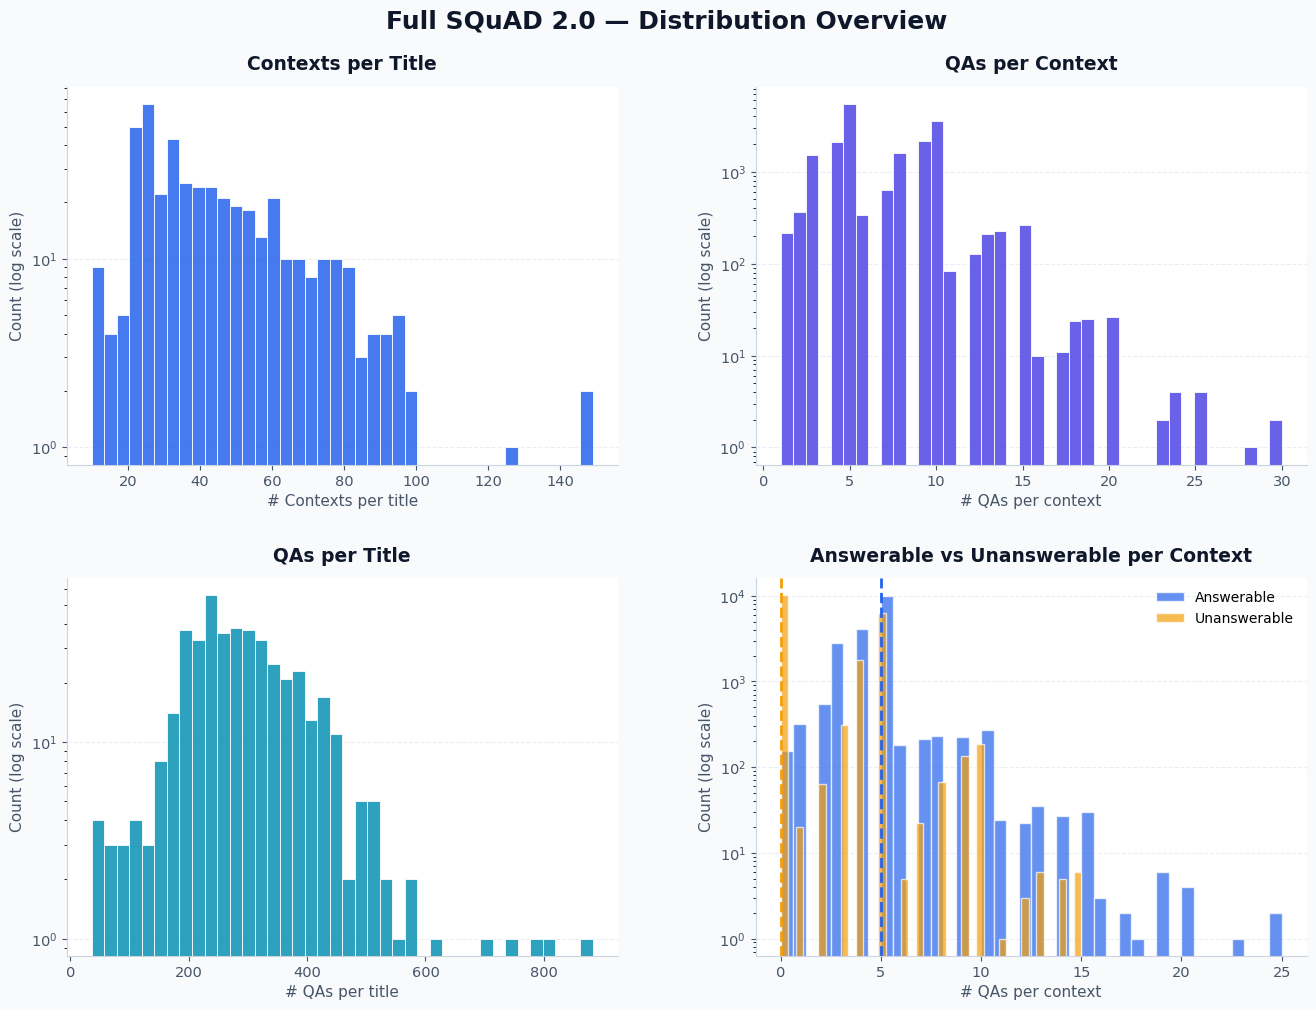

In [664]:
import matplotlib.pyplot as plt
import numpy as np

# ---------- Figure ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor('#F8FAFC')
axes = axes.flatten()

# ---------- Colors ----------
palette = {
    "blue":   "#2563EB",
    "indigo": "#4F46E5",
    "cyan":   "#0891B2",
    "orange": "#F59E0B"
}

grid_color  = "#E2E8F0"
title_color = "#0F172A"
label_color = "#475569"
spine_color = "#CBD5E1"

plot_configs = [
    (contexts_per_title, 'Contexts per Title', '# Contexts per title', palette["blue"]),
    (qas_per_context,    'QAs per Context',    '# QAs per context',    palette["indigo"]),
    (qas_per_title,      'QAs per Title',      '# QAs per title',      palette["cyan"]),
    (None,               'Answerable vs Unanswerable per Context', '# QAs per context', None),
]

for ax, (x, title, xlabel, color) in zip(axes, plot_configs):

    ax.set_facecolor('white')

    # spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(spine_color)
    ax.spines['bottom'].set_color(spine_color)

    # grid
    ax.yaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.7, color=grid_color)
    ax.set_axisbelow(True)

    # titles
    ax.set_title(title, fontsize=13.5, fontweight='bold', color=title_color, pad=12)
    ax.set_xlabel(xlabel, fontsize=11, color=label_color)
    ax.set_ylabel('Count (log scale)', fontsize=11, color=label_color)
    ax.tick_params(colors=label_color, labelsize=10.5)

    # ---------- single histograms ----------
    if x is not None:

        ax.hist(
            x,
            bins=40,
            color=color,
            edgecolor='white',
            linewidth=0.7,
            alpha=0.85
        )

    # ---------- comparison plot ----------
    else:

        ax.hist(
            ans_per_context,
            bins=40,
            alpha=0.70,
            label='Answerable',
            color=palette["blue"],
            edgecolor='white'
        )

        ax.hist(
            unans_per_context,
            bins=40,
            alpha=0.70,
            label='Unanswerable',
            color=palette["orange"],
            edgecolor='white'
        )

        # median lines (ONLY here)
        med_ans = np.median(ans_per_context)
        med_unans = np.median(unans_per_context)

        ax.axvline(med_ans, color=palette["blue"], linestyle='--', linewidth=2)
        ax.axvline(med_unans, color=palette["orange"], linestyle='--', linewidth=2)

        ax.legend(frameon=False, fontsize=10)

    ax.set_yscale('log')

fig.suptitle(
    'Full SQuAD 2.0 — Distribution Overview',
    fontsize=18,
    fontweight='bold',
    color=title_color,
    y=0.97
)

plt.subplots_adjust(top=0.90, hspace=0.30, wspace=0.25)
plt.show()

## 2. Dataset Sampling

From the full dataset we created a stratified sample of **~90,000 questions** (`train_sampled.json`) using `make_sampled_splits()`, maintaining a ~47% unanswerable ratio and covering all topics. All the following analysis is performed on this training split.

In [665]:
# -------- helpers ----------

def load_squad(path):
    # Load a SQuAD-format JSON file and return the parsed object
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def save_squad(obj, path):
    # Save a SQuAD-format object to a JSON file
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False)

def build_title_context_list(squad):
    # Flatten the nested SQuAD structure into a list of context-level dicts
    # Each entry contains the context text, its QAs, and answerable/unanswerable counts
    contexts = []
    ctx_id = 0
    for art in squad["data"]:
        title = art.get("title", "")
        for para in art["paragraphs"]:
            qas  = para["qas"]
            n_q  = len(qas)
            n_un = sum(bool(q.get("is_impossible", False)) for q in qas)
            contexts.append({
                "ctx_id":   ctx_id,
                "title":    title,
                "context":  para["context"],
                "qas":      qas,
                "n_q":      n_q,
                "n_un":     n_un,
                "n_an":     n_q - n_un,
                "un_ratio": (n_un / n_q) if n_q > 0 else 0.0,
                "has_un":   (n_un > 0),
            })
            ctx_id += 1
    return contexts

def allocate_contexts_per_title(contexts, n_total=2000, min_per_title=2, seed=42):
    # Allocate a fixed number of contexts per title, guaranteeing a minimum
    # and distributing the remainder proportionally to each title's size
    rnd = random.Random(seed)
    t2c = defaultdict(list)
    for c in contexts:
        t2c[c["title"]].append(c)

    titles     = list(t2c.keys())
    allocation = {t: min(min_per_title, len(t2c[t])) for t in titles}
    base       = sum(allocation.values())

    if base > n_total:
        raise ValueError("n_total too small relative to the minimum per title")

    remaining = n_total - base

    # Weight each title by its number of available extra contexts
    weights = np.array(
        [max(0, len(t2c[t]) - allocation[t]) for t in titles],
        dtype=float
    )

    if weights.sum() == 0:
        return allocation

    # Draw extra counts from a multinomial distribution
    probs        = weights / weights.sum()
    extra_counts = np.random.default_rng(seed).multinomial(remaining, probs)

    for t, extra in zip(titles, extra_counts):
        allocation[t] = min(allocation[t] + int(extra), len(t2c[t]))

    return allocation

def pick_qas_from_context(qas, rnd, cap, rem_an, rem_un):
    # Sample QAs from a single context, balancing answerable and unanswerable
    # until the cap or remaining budget is reached
    ans = [q for q in qas if not q.get("is_impossible", False)]
    un  = [q for q in qas if     q.get("is_impossible", False)]

    chosen = []
    cap    = min(cap, len(qas))

    while len(chosen) < cap and (rem_an > 0 or rem_un > 0) and (ans or un):
        need_un = rem_un > rem_an
        if need_un and rem_un > 0 and un:
            q = un.pop(rnd.randrange(len(un)));  chosen.append(q); rem_un -= 1
        elif (not need_un) and rem_an > 0 and ans:
            q = ans.pop(rnd.randrange(len(ans))); chosen.append(q); rem_an -= 1
        else:
            # Fallback: pick from whichever class still has budget
            if rem_un > 0 and un:
                q = un.pop(rnd.randrange(len(un)));  chosen.append(q); rem_un -= 1
            elif rem_an > 0 and ans:
                q = ans.pop(rnd.randrange(len(ans))); chosen.append(q); rem_an -= 1
            else:
                break

    # If nothing was chosen, keep at least one QA to avoid losing the context
    if not chosen and qas:
        q      = qas[rnd.randrange(len(qas))]
        chosen = [q]
        if q.get("is_impossible", False): rem_un = max(0, rem_un - 1)
        else:                             rem_an = max(0, rem_an - 1)

    return chosen, rem_an, rem_un

def build_squad_from_contexts(selected_contexts):
    # Reconstruct a SQuAD-format dict from a list of sampled context dicts
    bucket = defaultdict(lambda: defaultdict(list))
    for c in selected_contexts:
        bucket[c["title"]][c["context"]].extend(c["qas_selected"])

    data = []
    for title, ctx_map in bucket.items():
        paragraphs = [{"context": ctx, "qas": qas}
                      for ctx, qas in ctx_map.items()]
        data.append({"title": title, "paragraphs": paragraphs})
    return {"version": "v2.0", "data": data}

def stratified_split_by_context(selected_contexts, ratios=(0.8, 0.1, 0.1), seed=42):
    # Split contexts into train/val/test using stratification on the
    # unanswerable ratio bin — ensures balanced label distribution across splits
    rnd    = random.Random(seed)
    strata = defaultdict(list)

    for c in selected_contexts:
        r = c["un_ratio_selected"]
        if   r == 0:    key = "0"
        elif r <= 0.25: key = "0-0.25"
        elif r <= 0.5:  key = "0.25-0.5"
        else:           key = "0.5-1"
        strata[key].append(c)

    train, val, test = [], [], []
    for key, items in strata.items():
        rnd.shuffle(items)
        n       = len(items)
        n_train = int(round(n * ratios[0]))
        n_val   = int(round(n * ratios[1]))
        train.extend(items[:n_train])
        val.extend(items[n_train:n_train + n_val])
        test.extend(items[n_train + n_val:])

    return train, val, test


# -------- main pipeline ----------

def make_sampled_splits(
    in_path,
    out_train,
    out_val,
    out_test,
    target_qas_total=10000,
    target_unanswerable_ratio=0.4,
    n_contexts_total=2000,
    min_contexts_per_title=2,
    cap_qas_per_context=5,
    seed=42,
    quiet=False,
):
    rnd      = random.Random(seed)
    squad    = load_squad(in_path)
    contexts = build_title_context_list(squad)

    # Step 1 — allocate contexts per title
    alloc = allocate_contexts_per_title(
        contexts, n_total=n_contexts_total,
        min_per_title=min_contexts_per_title, seed=seed
    )

    # Step 2 — randomly select contexts for each title
    t2c = defaultdict(list)
    for c in contexts:
        t2c[c["title"]].append(c)

    selected_contexts = []
    for title, k in alloc.items():
        pool = t2c[title][:]
        rnd.shuffle(pool)
        selected_contexts.extend(pool[:k])
    rnd.shuffle(selected_contexts)

    # Step 3 — sample QAs within selected contexts to hit the target total
    target_un          = int(round(target_qas_total * target_unanswerable_ratio))
    target_an          = target_qas_total - target_un
    rem_an, rem_un     = target_an, target_un
    final_contexts     = []
    total_an = total_un = 0

    for c in selected_contexts:
        if total_an + total_un >= target_qas_total:
            break
        chosen_qas, rem_an, rem_un = pick_qas_from_context(
            c["qas"], rnd, cap_qas_per_context, rem_an, rem_un
        )
        if not chosen_qas:
            continue
        n_q  = len(chosen_qas)
        n_un = sum(bool(q.get("is_impossible", False)) for q in chosen_qas)
        n_an = n_q - n_un
        total_an += n_an
        total_un += n_un
        final_contexts.append({
            "ctx_id":           c["ctx_id"],
            "title":            c["title"],
            "context":          c["context"],
            "qas_selected":     chosen_qas,
            "un_ratio_selected":(n_un / n_q) if n_q else 0.0,
        })

    # Step 4 — stratified split by context
    train_ctx, val_ctx, test_ctx = stratified_split_by_context(
        final_contexts, seed=seed
    )

    # Step 5 — rebuild SQuAD format and save
    save_squad(build_squad_from_contexts(train_ctx), out_train)
    save_squad(build_squad_from_contexts(val_ctx),   out_val)
    save_squad(build_squad_from_contexts(test_ctx),  out_test)

    # Step 6 — build summary table
    def count_qas(ctx_list):
        tot = an = un = 0
        for c in ctx_list:
            tot += len(c["qas_selected"])
            un  += sum(bool(q.get("is_impossible", False))
                       for q in c["qas_selected"])
        an = tot - un
        return tot, an, un

    rows = []
    for name, ctx in [("TRAIN", train_ctx), ("VAL", val_ctx), ("TEST", test_ctx)]:
        tot, an, un = count_qas(ctx)
        rows.append({
            "Split":        name,
            "Contexts":     f"{len(ctx):,}",
            "Total QAs":    f"{tot:,}",
            "Answerable":   f"{an:,}  ({an/tot:.1%})",
            "Unanswerable": f"{un:,}  ({un/tot:.1%})",
        })

    total_tot = total_an + total_un
    rows.append({
        "Split":        "TOTAL",
        "Contexts":     "—",
        "Total QAs":    f"{total_tot:,}  (target: {target_qas_total:,})",
        "Answerable":   f"{total_an:,}  ({total_an/total_tot:.1%})",
        "Unanswerable": f"{total_un:,}  ({total_un/total_tot:.1%})",
    })

    if not quiet:
        display(show_table(
            pd.DataFrame(rows),
            caption="Sampled Splits - Summary",
            n=len(rows)
        ))

In [666]:
# Run the sampling pipeline
random.seed(123)

make_sampled_splits(
    "train-v2.0.json",
    "train_sampled.json",
    "val_sampled.json",
    "test_sampled.json",
    target_qas_total=90000,
    target_unanswerable_ratio=0.47,
    n_contexts_total=17000,
    min_contexts_per_title=2,
    cap_qas_per_context=20,
    seed=42
)

Split,Contexts,Total QAs,Answerable,Unanswerable
TRAIN,"13,307","70,807","40,633 (57.4%)","30,174 (42.6%)"
VAL,"1,664","8,913","5,170 (58.0%)","3,743 (42.0%)"
TEST,"1,663","8,990","5,233 (58.2%)","3,757 (41.8%)"
TOTAL,—,"88,710 (target: 90,000)","51,036 (57.5%)","37,674 (42.5%)"


In [667]:
# Flattens the hierarchical JSON into a flat pandas DataFrame: one row per question-answer pair
def squad2_to_df(path: str) -> pd.DataFrame:
    with open(path, 'r', encoding='utf-8') as f:
        squad = json.load(f)
    
    rows = []
    # Iterate over the three nested levels: article, paragraph, and question
    for article in squad['data']:
        title = article['title']
        for para in article['paragraphs']:
            context = para['context']
            for qa in para['qas']:
                is_impossible = qa.get('is_impossible', False)
                answers = qa.get('answers', [])
                
                # If the question is answerable, extract text and position;
                # otherwise mark as NO_ANSWER with start position -1
                ans_text  = answers[0]['text']         if answers else 'NO_ANSWER'
                ans_start = answers[0]['answer_start'] if answers else -1
                
                rows.append({
                    'id':            qa.get('id', ''),
                    'title':         title,
                    'context':       context,
                    'question':      qa.get('question', ''),
                    'is_impossible': is_impossible,
                    'y':             0 if is_impossible else 1,  # binary label
                    'answer_text':   ans_text,
                    'answer_start':  ans_start,
                })
    
    return pd.DataFrame(rows)


# Adds engineered features to the DataFrame: text cleaning, length metrics, WH-word category, and question-context token overlap
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()  # avoid modifying the original DataFrame
    
    # Remove extra whitespace from questions and contexts
    df['question'] = df['question'].apply(lambda s: re.sub(r'\s+', ' ', str(s).strip()))
    df['context']  = df['context'].apply(lambda s: re.sub(r'\s+', ' ', str(s).strip()))
    
    # Compute length in tokens (whitespace split) and characters
    df['q_len_tok']  = df['question'].str.split().str.len()
    df['c_len_tok']  = df['context'].str.split().str.len()
    df['q_len_char'] = df['question'].str.len()
    df['c_len_char'] = df['context'].str.len()
    df['a_len_tok']  = df['answer_text'].str.split().str.len()
    df.loc[df['answer_text'] == 'NO_ANSWER', 'a_len_tok'] = 0  # unanswerable → 0
    
    # Classify each question by its interrogative word (what, who, when, ...)
    def wh_cat(q):
        q = str(q).lower()
        for w in WH_WORDS:
            if re.search(rf'\b{w}\b', q):
                return w
        return 'other'
    df['wh'] = df['question'].map(wh_cat)
    
    # Compute fraction of question tokens that also appear in the context
    # Higher overlap more likely to be answerable
    def overlap(q, c):
        qt = set(str(q).lower().split())
        ct = set(str(c).lower().split())
        return len(qt & ct) / len(qt) if qt else 0.0
    df['overlap'] = [overlap(q, c) for q, c in zip(df['question'], df['context'])]
    
    return df

train_df = squad2_to_df('train_sampled.json')
train_df = add_features(train_df)

In [668]:
print(f'Shape: {train_df.shape}')
preview_cols = ['title', 'question', 'is_impossible', 'y', 'answer_text', 'q_len_tok', 'c_len_tok', 'wh', 'overlap']
display(show_table(train_df[preview_cols], caption='Training Set — First 5 rows'))

Shape: (70807, 15)


title,question,is_impossible,y,answer_text,q_len_tok,c_len_tok,wh,overlap
Myanmar,Who was involved merger of the smaller states into the two largest factions of Myanmar ?,False,1,Ava Kingdom and Hanthawaddy Kingdom,16,104,who,0.500000
Myanmar,What is the name of the kingdom that became dominant along the coastline of Myanmar?,False,1,Kingdom of Mrauk U,15,104,what,0.416667
Myanmar,Did the Mongol invasions of Burma leave any lasting signs?,False,1,Shan migrants who arrived with the Mongol invasions stayed behind,10,104,other,0.400000
Myanmar,How long did it take for Myanmar to recover from the collapse of it's first kingdom ?,False,1,250 years,17,104,how,0.411765
Myanmar,"Who was the ruling monarchy when Taungoo, was vassal?",False,1,king Tabinshwehti,9,101,who,0.250000


## 3. Data Quality Check

### 3.1 Missing Values

Before any analysis, we check for missing values across all columns. This is a fundamental data quality step. Missing values can silently distort statistics and model performance.

In [669]:
# Check for missing values across all columns — fundamental data quality step
missing = train_df.isnull().sum()
display(show_table(
    pd.DataFrame({'Column': missing.index, 'Missing Values': missing.values}),
    caption='Missing Values per Column',
    n=len(missing)
))
print(f'No missing values found — dataset is complete ({len(train_df):,} rows).')

Column,Missing Values
id,0
title,0
context,0
question,0
is_impossible,0
y,0
answer_text,0
answer_start,0
q_len_tok,0
c_len_tok,0


No missing values found — dataset is complete (70,807 rows).


## 4. Exploratory Data Analysis

### 4.1 Label Distribution

SQuAD 2.0 introduces unanswerable questions (y=0) alongside answerable ones (y=1). We verify that the target unanswerable ratio (~47%) was correctly achieved by the sampling procedure.

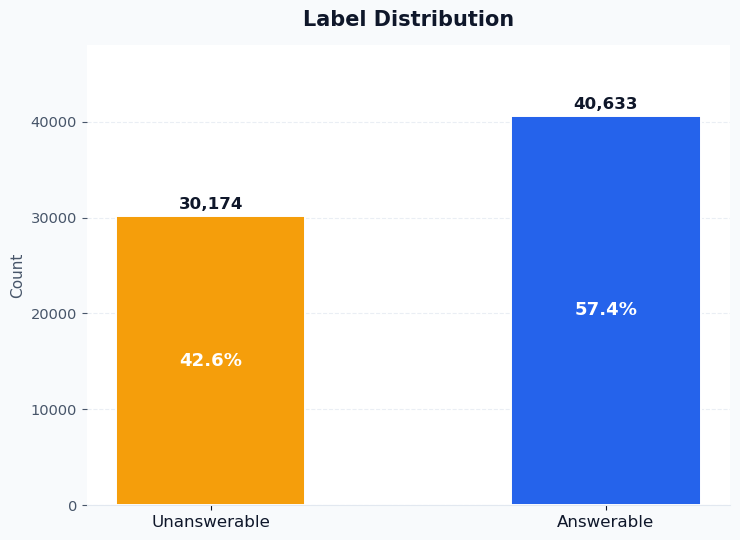

In [670]:
counts = train_df['y'].value_counts().sort_index()

labels = ['Unanswerable', 'Answerable']
values = [counts.get(0, 0), counts.get(1, 0)]
total  = sum(values)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
fig.patch.set_facecolor('#F8FAFC')
ax.set_facecolor('white')

# palette coerente con il resto dell'EDA
colors = ['#F59E0B', '#2563EB']  # orange, blue

bars = ax.bar(
    labels,
    values,
    color=colors,
    width=0.48,
    edgecolor='white',
    linewidth=1.4
)

# ---------- absolute counts above bars ----------
for bar, v in zip(bars, values):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + total * 0.006,
        f'{v:,}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color='#0F172A'
    )

# ---------- percentages inside bars ----------
for bar, v in zip(bars, values):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()/2,
        f'{v/total*100:.1f}%',
        ha='center',
        va='center',
        fontsize=13,
        fontweight='bold',
        color='white'
    )

# ---------- titles and axes ----------
ax.set_title(
    'Label Distribution',
    fontsize=15,
    fontweight='bold',
    pad=14,
    color='#0F172A'
)

ax.set_ylabel(
    'Count',
    fontsize=11,
    color='#475569'
)

ax.set_ylim(0, max(values) * 1.18)

# ---------- style ----------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#E2E8F0')

ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='#E2E8F0')
ax.set_axisbelow(True)

ax.tick_params(axis='y', labelsize=10.5, colors='#475569')
ax.tick_params(axis='x', labelsize=12, colors='#0F172A')

plt.tight_layout()
plt.show()

### 4.2 Length Statistics

We analyze the length distributions of questions, contexts, and answers (in tokens). This is important for choosing the tokenizer's `MAX_LENGTH` and for understanding how the dataset is structured. Answerable and unanswerable questions are compared side by side.

Feature,count,mean,std,min,50%,75%,90%,95%,99%,max
q_len_tok,70807.000000,9.800000,3.400000,1.000000,9.000000,12.000000,14.000000,16.000000,20.000000,34.000000
c_len_tok,70807.000000,119.300000,49.200000,20.000000,109.000000,141.000000,182.000000,211.000000,286.000000,653.000000
a_len_tok,70807.000000,1.800000,2.900000,0.000000,1.000000,2.000000,5.000000,7.000000,15.000000,43.000000


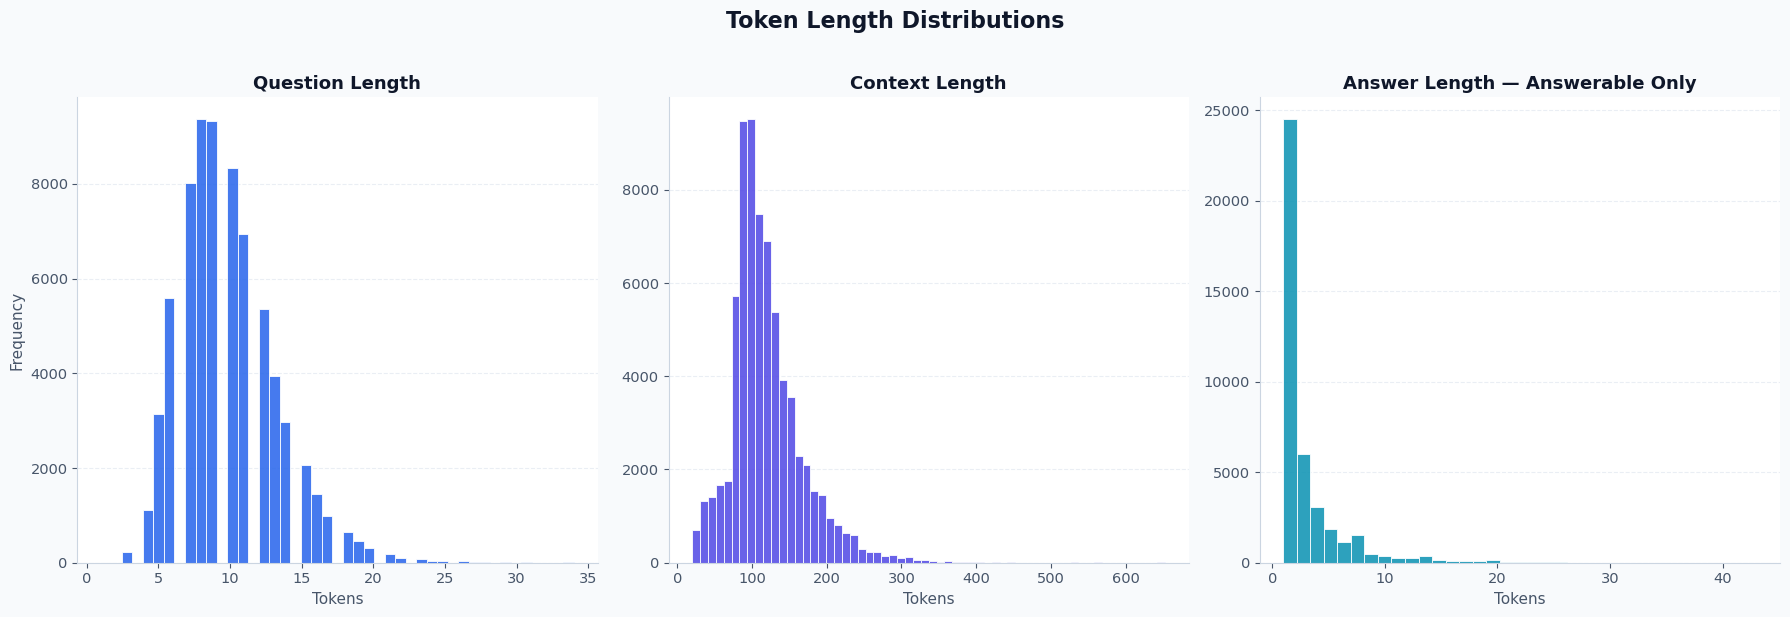

In [671]:
# Summary statistics for question, context and answer lengths in tokens
cols = ['q_len_tok', 'c_len_tok', 'a_len_tok']

display(show_table(
    train_df[cols].describe(percentiles=[.5, .75, .9, .95, .99])
                  .T.round(1)
                  .reset_index()
                  .rename(columns={'index': 'Feature'}),
    caption='Length Summary Statistics (tokens)',
    n=len(cols)
))

# Plot length distributions for questions, contexts and answers
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#F8FAFC')

grid_color  = '#E2E8F0'
title_color = '#0F172A'
label_color = '#475569'
spine_color = '#CBD5E1'

for ax in axes:

    ax.set_facecolor('white')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(spine_color)
    ax.spines['bottom'].set_color(spine_color)

    ax.yaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.7, color=grid_color)
    ax.set_axisbelow(True)

    ax.tick_params(colors=label_color, labelsize=10.5)

# ---------- Question length ----------
axes[0].hist(
    train_df['q_len_tok'],
    bins=45,
    color='#2563EB',
    alpha=0.85,
    edgecolor='white',
    linewidth=0.7
)

axes[0].set_title(
    'Question Length',
    fontsize=13,
    fontweight='bold',
    color=title_color
)

axes[0].set_xlabel('Tokens', fontsize=11, color=label_color)
axes[0].set_ylabel('Frequency', fontsize=11, color=label_color)

# ---------- Context length ----------
axes[1].hist(
    train_df['c_len_tok'],
    bins=60,
    color='#4F46E5',
    alpha=0.85,
    edgecolor='white',
    linewidth=0.7
)

axes[1].set_title(
    'Context Length',
    fontsize=13,
    fontweight='bold',
    color=title_color
)

axes[1].set_xlabel('Tokens', fontsize=11, color=label_color)

# ---------- Answer length ----------
ans = train_df.loc[train_df['y'] == 1, 'a_len_tok']

axes[2].hist(
    ans,
    bins=35,
    color='#0891B2',
    alpha=0.85,
    edgecolor='white',
    linewidth=0.7
)

axes[2].set_title(
    'Answer Length — Answerable Only',
    fontsize=13,
    fontweight='bold',
    color=title_color
)

axes[2].set_xlabel('Tokens', fontsize=11, color=label_color)

plt.suptitle(
    'Token Length Distributions',
    fontsize=16,
    fontweight='bold',
    color=title_color,
    y=1.02
)

plt.tight_layout()
plt.show()

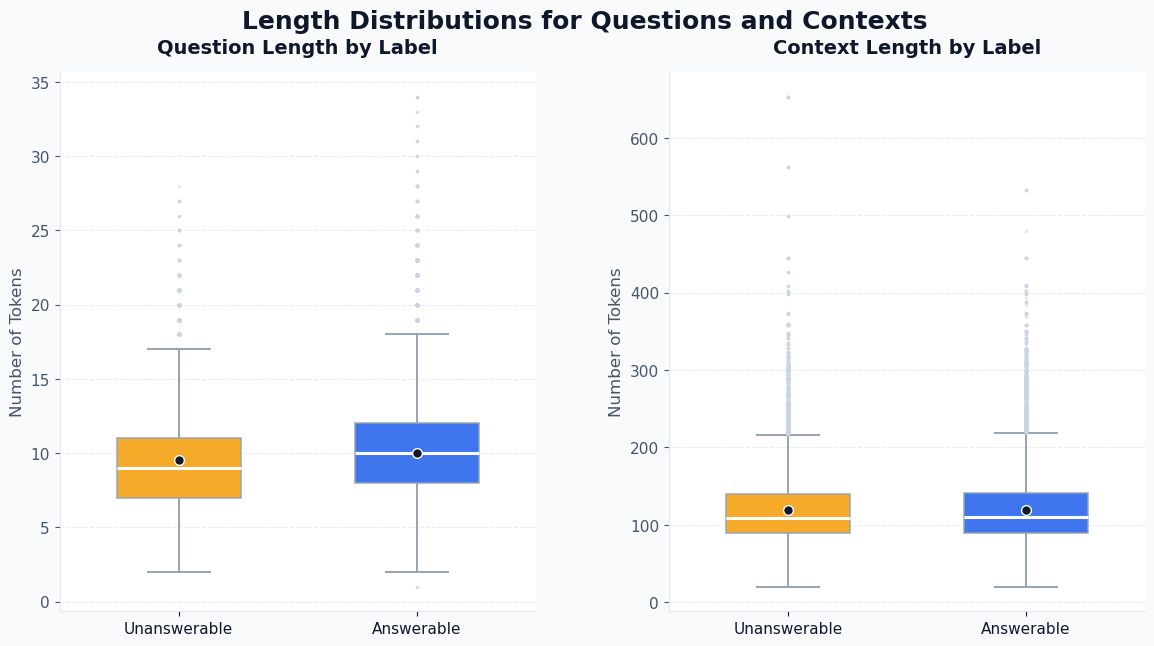

In [672]:
# ---------- Style ----------
bg_color    = '#F8FAFC'
edge_color  = '#94A3B8'
title_color = '#0F172A'
label_color = '#475569'
grid_color  = '#E2E8F0'

# palette coerente con gli altri grafici
box_colors  = ['#F59E0B', '#2563EB']  # unanswerable, answerable

# ---------- Data ----------
plot_data = [
    (
        [train_df.loc[train_df['y']==0, 'q_len_tok'],
         train_df.loc[train_df['y']==1, 'q_len_tok']],
        'Question Length by Label'
    ),
    (
        [train_df.loc[train_df['y']==0, 'c_len_tok'],
         train_df.loc[train_df['y']==1, 'c_len_tok']],
        'Context Length by Label'
    ),
]

# ---------- Figure ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor(bg_color)

for ax, (data, title) in zip(axes, plot_data):

    ax.set_facecolor('white')

    bp = ax.boxplot(
        data,
        labels=['Unanswerable', 'Answerable'],
        patch_artist=True,
        widths=0.52,
        showmeans=True,

        medianprops=dict(color='white', linewidth=2.2),

        meanprops=dict(
            marker='o',
            markerfacecolor='#111827',
            markeredgecolor='white',
            markersize=7
        ),

        whiskerprops=dict(color=edge_color, linewidth=1.4),
        capprops=dict(color=edge_color, linewidth=1.4),
        boxprops=dict(edgecolor=edge_color, linewidth=1.2),

        flierprops=dict(
            marker='o',
            markersize=2.5,
            markerfacecolor='#CBD5E1',
            markeredgecolor='none',
            alpha=0.5
        )
    )

    # Apply colors
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.88)

    ax.set_title(
        title,
        fontsize=14,
        fontweight='bold',
        color=title_color,
        pad=14
    )

    ax.set_ylabel(
        'Number of Tokens',
        fontsize=12,
        color=label_color
    )

    # Grid
    ax.yaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.75, color=grid_color)
    ax.set_axisbelow(True)

    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(grid_color)
    ax.spines['bottom'].set_color(grid_color)

    ax.tick_params(axis='x', labelsize=11, colors=title_color)
    ax.tick_params(axis='y', labelsize=11, colors=label_color)

# ---------- Title ----------
fig.suptitle(
    'Length Distributions for Questions and Contexts',
    fontsize=18,
    fontweight='bold',
    color=title_color,
    y=0.97
)

plt.subplots_adjust(
    top=0.88,
    wspace=0.28
)

plt.show()

### 4.3 Answer Position in Context

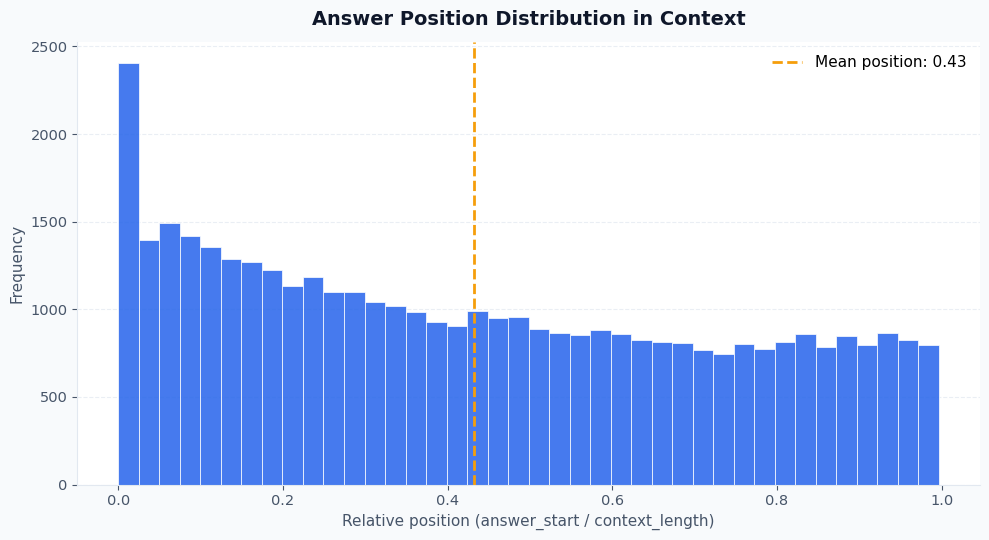

Mean relative position,Median relative position,Answers in first 25%,Answers in first 50%,Answers in first 75%
0.432,0.398,34.9%,59.5%,80.0%


In [673]:
# Compute relative answer position: answer_start / context_length
# Only for answerable questions
ans_df = train_df[train_df['y'] == 1].copy()
ans_df['rel_pos'] = ans_df['answer_start'] / ans_df['c_len_char']

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor('#F8FAFC')
ax.set_facecolor('white')

# Histogram
ax.hist(
    ans_df['rel_pos'],
    bins=40,
    color='#2563EB',
    edgecolor='white',
    linewidth=0.6,
    alpha=0.85
)

# Titles and labels
ax.set_title(
    'Answer Position Distribution in Context',
    fontsize=14,
    fontweight='bold',
    color='#0F172A',
    pad=12
)

ax.set_xlabel(
    'Relative position (answer_start / context_length)',
    fontsize=11,
    color='#475569'
)

ax.set_ylabel(
    'Frequency',
    fontsize=11,
    color='#475569'
)

# Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#E2E8F0')
ax.spines['bottom'].set_color('#E2E8F0')

ax.yaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.7, color='#E2E8F0')
ax.set_axisbelow(True)

ax.tick_params(axis='x', labelsize=10.5, colors='#475569')
ax.tick_params(axis='y', labelsize=10.5, colors='#475569')

# ---------- Mean line ----------
mean_pos = ans_df['rel_pos'].mean()

ax.axvline(
    mean_pos,
    color='#F59E0B',
    linestyle='--',
    linewidth=2,
    label=f'Mean position: {mean_pos:.2f}'
)

ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

# ---------- Summary table ----------
display(show_table(
    pd.DataFrame([{
        'Mean relative position':   f'{ans_df["rel_pos"].mean():.3f}',
        'Median relative position': f'{ans_df["rel_pos"].median():.3f}',
        'Answers in first 25%':     f'{(ans_df["rel_pos"] < 0.25).mean():.1%}',
        'Answers in first 50%':     f'{(ans_df["rel_pos"] < 0.50).mean():.1%}',
        'Answers in first 75%':     f'{(ans_df["rel_pos"] < 0.75).mean():.1%}',
    }]),
    caption='Answer Position Statistics',
    n=1
))

### 4.4 Context Length and Model Constraints

Since transformer models have a fixed input length limit, we analyze how many contexts exceed common thresholds. This motivates the choice of `MAX_LENGTH=384` for DeBERTa and the use of a sliding window with overlap to avoid losing answer spans during truncation.

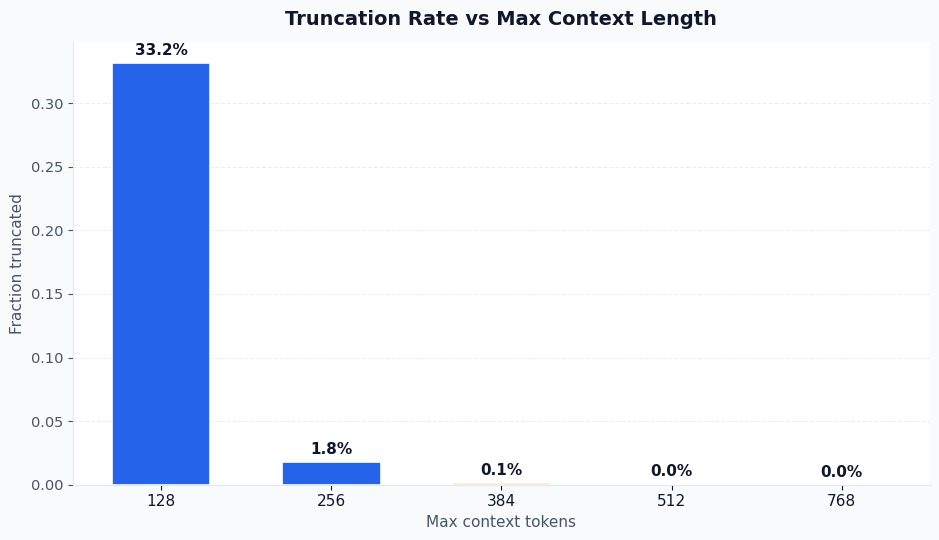

In [674]:
# Bar chart — chosen threshold (384) highlighted
fig, ax = plt.subplots(figsize=(9.5, 5.5))
fig.patch.set_facecolor('#F8FAFC')
ax.set_facecolor('white')

# palette coerente
colors = ['#F59E0B' if t == 384 else '#2563EB' for t in thresholds]

bars = ax.bar(
    [str(t) for t in thresholds],
    rates,
    color=colors,
    edgecolor='white',
    linewidth=1.2,
    width=0.58
)

# value labels
for bar, r in zip(bars, rates):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.004,
        f'{r:.1%}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='#0F172A'
    )

# title and labels
ax.set_title(
    'Truncation Rate vs Max Context Length',
    fontsize=14,
    fontweight='bold',
    color='#0F172A',
    pad=12
)

ax.set_xlabel(
    'Max context tokens',
    fontsize=11,
    color='#475569'
)

ax.set_ylabel(
    'Fraction truncated',
    fontsize=11,
    color='#475569'
)

# style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#E2E8F0')
ax.spines['bottom'].set_color('#E2E8F0')

ax.yaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.7, color='#E2E8F0')
ax.set_axisbelow(True)

ax.tick_params(axis='x', labelsize=11, colors='#0F172A')
ax.tick_params(axis='y', labelsize=10.5, colors='#475569')

plt.tight_layout()
plt.show()

### 4.5 Question - Context Token Overlap

For each question, we compute the fraction of question tokens that also appear in the context. Answerable questions tend to have higher overlap because the answer is extracted from the context and share vocabulary with the question.

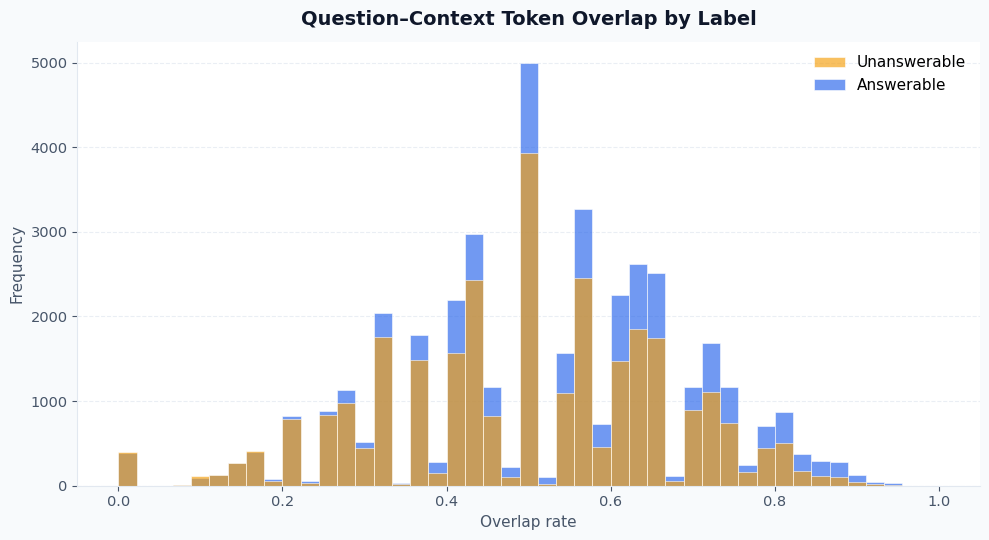

Label,Mean Overlap
Unanswerable,0.496000
Answerable,0.519000


In [675]:
# Overlapping histograms showing token overlap distribution by label

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor('#F8FAFC')
ax.set_facecolor('white')

# histograms
ax.hist(
    train_df.loc[train_df['y']==0, 'overlap'],
    bins=45,
    alpha=0.65,
    label='Unanswerable',
    color='#F59E0B',
    edgecolor='white',
    linewidth=0.6,
    zorder=2
)

ax.hist(
    train_df.loc[train_df['y']==1, 'overlap'],
    bins=45,
    alpha=0.65,
    label='Answerable',
    color='#2563EB',
    edgecolor='white',
    linewidth=0.6,
    zorder=1
)

# titles
ax.set_title(
    'Question–Context Token Overlap by Label',
    fontsize=14,
    fontweight='bold',
    color='#0F172A',
    pad=12
)

ax.set_xlabel(
    'Overlap rate',
    fontsize=11,
    color='#475569'
)

ax.set_ylabel(
    'Frequency',
    fontsize=11,
    color='#475569'
)

# style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#E2E8F0')
ax.spines['bottom'].set_color('#E2E8F0')

ax.yaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.7, color='#E2E8F0')
ax.set_axisbelow(True)

ax.tick_params(axis='x', labelsize=10.5, colors='#475569')
ax.tick_params(axis='y', labelsize=10.5, colors='#475569')

ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()


# Mean overlap table (unchanged style)
overlap_table = (
    train_df.groupby('y')['overlap']
    .mean()
    .rename({0: 'Unanswerable', 1: 'Answerable'})
    .round(3)
    .reset_index()
    .rename(columns={'y': 'Label', 'overlap': 'Mean Overlap'})
)

display(show_table(
    overlap_table,
    caption='Mean Token Overlap Between Question and Context',
    n=len(overlap_table)
))

### 4.6 Question Type Analysis (WH-Words)

We classify each question by its interrogative word (what, who, when, where, why, how, which). The stacked bar chart shows how answerability varies by question type — 'when' and 'where' questions tend to be more answerable because dates and locations are easy to locate in text.

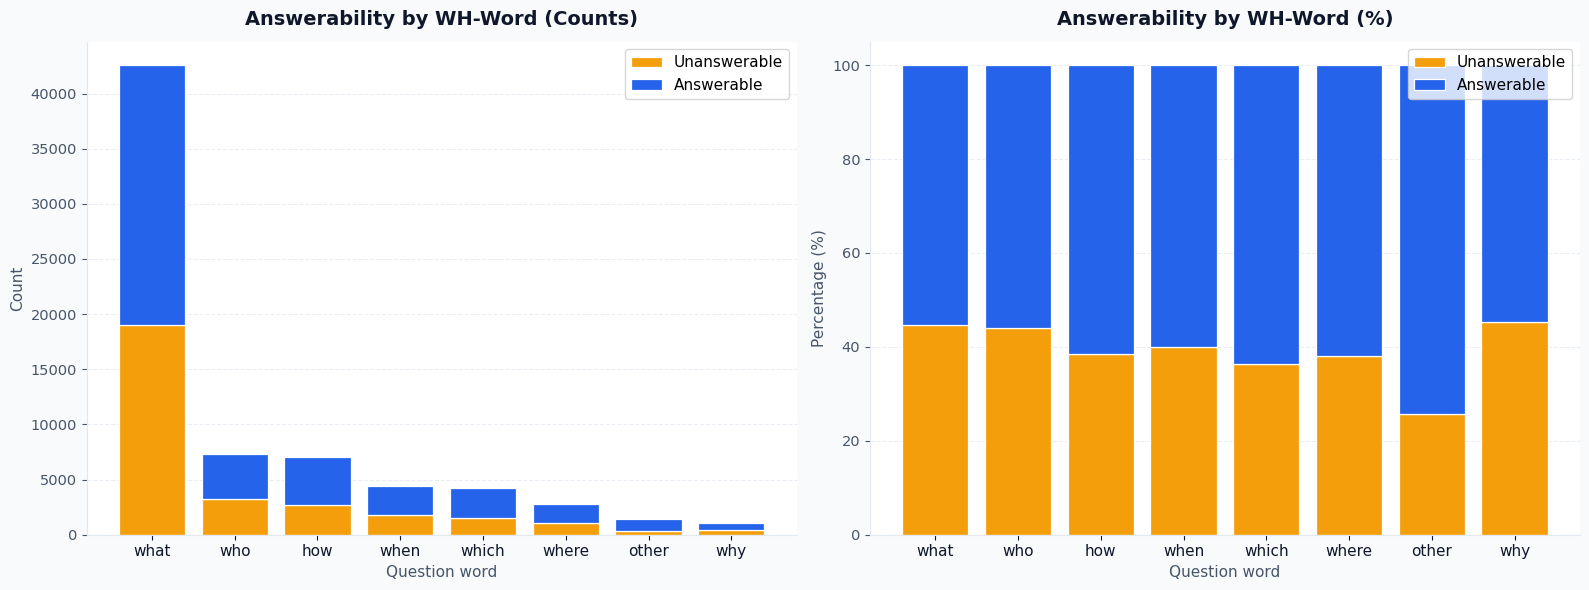

In [676]:
# Stacked bar charts showing answerability distribution by WH-word

counts = train_df.groupby(['wh', 'y']).size().unstack(fill_value=0)

if 0 not in counts.columns: counts[0] = 0
if 1 not in counts.columns: counts[1] = 0

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=False).index]

# Normalize to percentages
perc = counts.div(counts.sum(axis=1), axis=0) * 100

# ---------- Figure ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#F8FAFC')

title_color = '#0F172A'
label_color = '#475569'
grid_color  = '#E2E8F0'

for ax, data, title, ylabel in zip(
    axes,
    [(counts[0], counts[1]), (perc[0], perc[1])],
    ['Answerability by WH-Word (Counts)', 'Answerability by WH-Word (%)'],
    ['Count', 'Percentage (%)']
):

    ax.set_facecolor('white')

    # Unanswerable bottom
    ax.bar(
        data[0].index,
        data[0],
        label='Unanswerable',
        color='#F59E0B',
        edgecolor='white',
        linewidth=0.9
    )

    # Answerable stacked
    ax.bar(
        data[1].index,
        data[1],
        bottom=data[0],
        label='Answerable',
        color='#2563EB',
        edgecolor='white',
        linewidth=0.9
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight='bold',
        color=title_color,
        pad=12
    )

    ax.set_xlabel(
        'Question word',
        fontsize=11,
        color=label_color
    )

    ax.set_ylabel(
        ylabel,
        fontsize=11,
        color=label_color
    )

    # style
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(grid_color)
    ax.spines['bottom'].set_color(grid_color)

    ax.yaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.7, color=grid_color)
    ax.set_axisbelow(True)

    ax.tick_params(axis='x', labelsize=11, colors=title_color)
    ax.tick_params(axis='y', labelsize=10.5, colors=label_color)

    ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

### 4.7 Token and Bigram Frequency

The most frequent tokens and bigrams in questions reveal the semantic patterns of the dataset. Stopwords are removed to focus on content words.

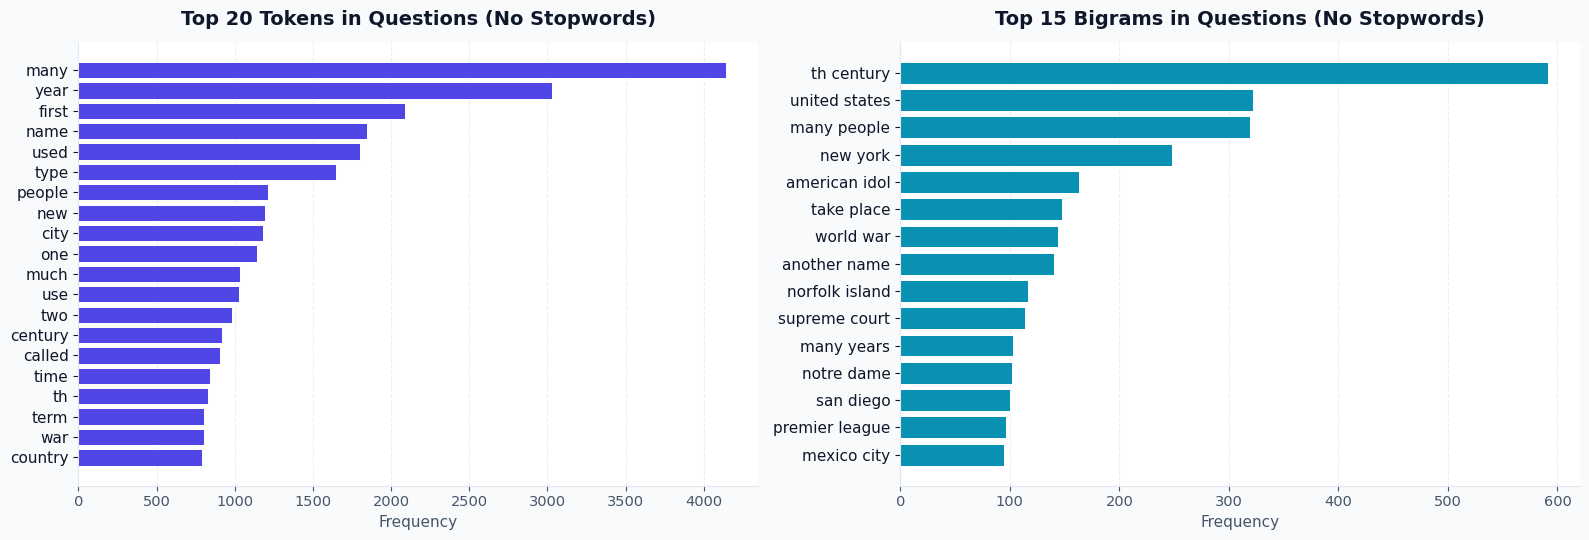

In [677]:
# Tokenize text using regex — extracts alphabetic words, lowercased
def tokenize(text):
    return [t.lower() for t in TOKEN_RE.findall(str(text)) if t]

# Count the k most frequent tokens across all texts, excluding stopwords
def top_tokens(texts, k=20):
    c = Counter()
    for t in texts:
        c.update([w for w in tokenize(t) if w not in STOP])
    return c.most_common(k)

# Count the k most frequent bigrams (2-word sequences) excluding stopwords
def top_bigrams(texts, k=15):
    c = Counter()
    for t in texts:
        toks = [w for w in tokenize(t) if w not in STOP]
        c.update(list(ngrams(toks, 2)))
    return c.most_common(k)

# ---------- Figure ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor('#F8FAFC')

title_color = '#0F172A'
label_color = '#475569'
grid_color  = '#E2E8F0'

# ---------- Top tokens ----------
common_tok = top_tokens(train_df['question'], k=20)
words = [w for w, _ in common_tok][::-1]
freqs = [f for _, f in common_tok][::-1]

axes[0].barh(
    words,
    freqs,
    color='#4F46E5',  # indigo
    edgecolor='white',
    linewidth=0.7
)

axes[0].set_title(
    'Top 20 Tokens in Questions (No Stopwords)',
    fontsize=14,
    fontweight='bold',
    color=title_color,
    pad=12
)

axes[0].set_xlabel(
    'Frequency',
    fontsize=11,
    color=label_color
)

# ---------- Top bigrams ----------
common_bi = top_bigrams(train_df['question'], k=15)
labels = [' '.join(g) for g, _ in common_bi][::-1]
freqs_bi = [f for _, f in common_bi][::-1]

axes[1].barh(
    labels,
    freqs_bi,
    color='#0891B2',  # cyan
    edgecolor='white',
    linewidth=0.7
)

axes[1].set_title(
    'Top 15 Bigrams in Questions (No Stopwords)',
    fontsize=14,
    fontweight='bold',
    color=title_color,
    pad=12
)

axes[1].set_xlabel(
    'Frequency',
    fontsize=11,
    color=label_color
)

# ---------- Shared styling ----------
for ax in axes:

    ax.set_facecolor('white')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(grid_color)
    ax.spines['bottom'].set_color(grid_color)

    ax.xaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.7, color=grid_color)
    ax.set_axisbelow(True)

    ax.tick_params(axis='x', labelsize=10.5, colors=label_color)
    ax.tick_params(axis='y', labelsize=11, colors=title_color)

plt.tight_layout()
plt.show()

### 4.8 Ansewrability by Topic

We look at the top 10 most frequent Wikipedia topics in the dataset and compare the proportion of answerable vs unanswerable questions for each. Some topics have been annotated with more unanswerable questions than others.

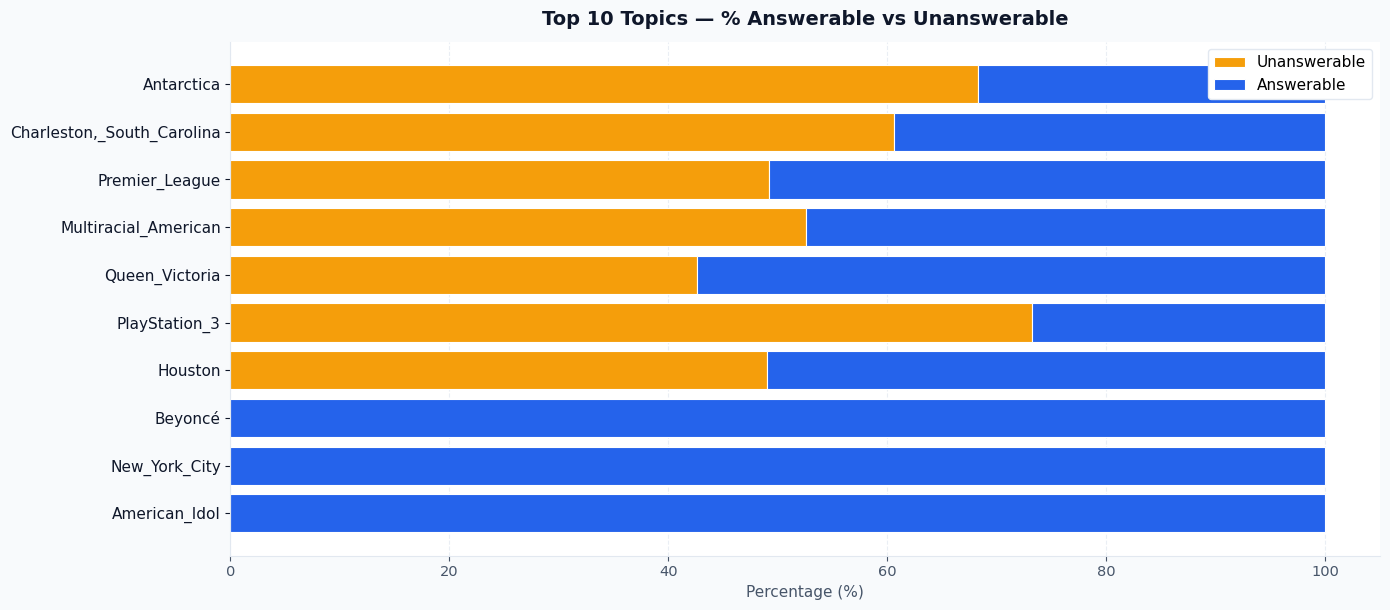

In [678]:
# Select the 10 most frequent Wikipedia topics in the dataset
TOP_N = 10
top_t  = train_df['title'].value_counts().head(TOP_N).index
tmp    = train_df[train_df['title'].isin(top_t)]

# Count answerable/unanswerable per topic and normalize to percentages
counts = tmp.groupby(['title', 'y']).size().unstack(fill_value=0)
if 0 not in counts.columns:
    counts[0] = 0
if 1 not in counts.columns:
    counts[1] = 0

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=False).index]
perc   = counts.div(counts.sum(axis=1), axis=0) * 100
titles = perc.index.tolist()

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=(14, 6.2))
fig.patch.set_facecolor('#F8FAFC')
ax.set_facecolor('white')

# Horizontal stacked bars
ax.barh(
    titles,
    perc[0],
    label='Unanswerable',
    color='#F59E0B',
    edgecolor='white',
    linewidth=0.8
)

ax.barh(
    titles,
    perc[1],
    left=perc[0],
    label='Answerable',
    color='#2563EB',
    edgecolor='white',
    linewidth=0.8
)

# ---------- Titles and labels ----------
ax.set_title(
    f'Top {TOP_N} Topics — % Answerable vs Unanswerable',
    fontsize=14,
    fontweight='bold',
    color='#0F172A',
    pad=12
)

ax.set_xlabel(
    'Percentage (%)',
    fontsize=11,
    color='#475569'
)

# ---------- Style ----------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#E2E8F0')
ax.spines['bottom'].set_color('#E2E8F0')

ax.xaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.7, color='#E2E8F0')
ax.set_axisbelow(True)

ax.tick_params(axis='x', labelsize=10.5, colors='#475569')
ax.tick_params(axis='y', labelsize=11, colors='#0F172A')

ax.legend(
    frameon=True,
    facecolor='white',
    edgecolor='#E2E8F0',
    framealpha=1,
    fontsize=11
)

plt.tight_layout()
plt.show()

## 5. Linguistic Analysis

### 5.1 Named Entity Recognition - NER

Using spaCy, we extract named entities from a sample of questions and contexts. This shows what types of entities are most referenced in the dataset (people, locations, organizations, dates, etc.) and whether the distribution differs between questions and contexts.

Processing NER on questions...
Processing NER on contexts...


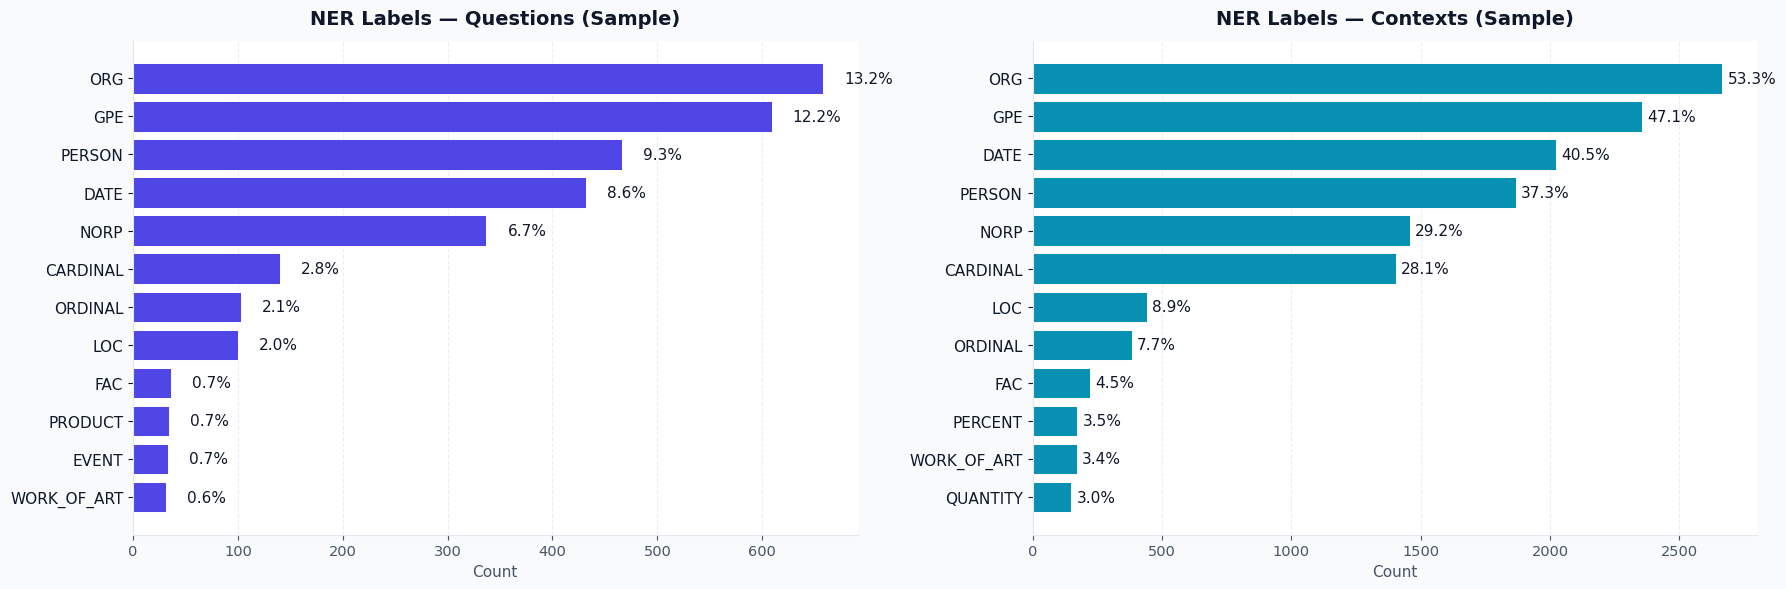

In [679]:
# Sample questions and unique contexts for NER analysis
SAMPLE_N = 3000
sample_q = train_df['question'].sample(min(SAMPLE_N, len(train_df)), random_state=42).tolist()
sample_c = train_df['context'].drop_duplicates().sample(
    min(1000, train_df['context'].nunique()), random_state=42
).tolist()

# Run spaCy NER pipeline in batches
print('Processing NER on questions...')
docs_q = list(nlp.pipe(sample_q, batch_size=64))
print('Processing NER on contexts...')
docs_c = list(nlp.pipe(sample_c, batch_size=32))

# Count entity label frequencies
ner_q = Counter([ent.label_ for d in docs_q for ent in d.ents])
ner_c = Counter([ent.label_ for d in docs_c for ent in d.ents])

# ---------- Figure ----------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#F8FAFC')

title_color = '#0F172A'
label_color = '#475569'
grid_color  = '#E2E8F0'

# ---------- Questions ----------
items_q = ner_q.most_common(12)
labels_q = [k for k, _ in items_q][::-1]
vals_q   = [v for _, v in items_q][::-1]
tot_q    = sum(vals_q)

bars_q = axes[0].barh(
    labels_q,
    vals_q,
    color='#4F46E5',
    edgecolor='white',
    linewidth=0.7
)

for bar, v in zip(bars_q, vals_q):
    axes[0].text(
        bar.get_width() + total_t * 0.004,
        bar.get_y() + bar.get_height() / 2,
        f'{v / total_t:.1%}',
        va='center',
        fontsize=11,
        color='#0F172A'
    )

axes[0].set_title(
    'NER Labels — Questions (Sample)',
    fontsize=14,
    fontweight='bold',
    color=title_color,
    pad=12
)

axes[0].set_xlabel('Count', fontsize=11, color=label_color)


# ---------- Contexts ----------
items_c = ner_c.most_common(12)
labels_c = [k for k, _ in items_c][::-1]
vals_c   = [v for _, v in items_c][::-1]
tot_c    = sum(vals_c)

bars_c = axes[1].barh(
    labels_c,
    vals_c,
    color='#0891B2',
    edgecolor='white',
    linewidth=0.7
)

for bar, v in zip(bars_c, vals_c):
    axes[1].text(
        bar.get_width() + total_t * 0.004,
        bar.get_y() + bar.get_height() / 2,
        f'{v / total_t:.1%}',
        va='center',
        fontsize=11,
        color='#0F172A'
    )

axes[1].set_title(
    'NER Labels — Contexts (Sample)',
    fontsize=14,
    fontweight='bold',
    color=title_color,
    pad=12
)

axes[1].set_xlabel('Count', fontsize=11, color=label_color)


# ---------- Shared style ----------
for ax in axes:
    ax.set_facecolor('white')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(grid_color)
    ax.spines['bottom'].set_color(grid_color)

    ax.xaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.7, color=grid_color)
    ax.set_axisbelow(True)

    ax.tick_params(axis='x', labelsize=10.5, colors=label_color)
    ax.tick_params(axis='y', labelsize=11, colors=title_color)

plt.tight_layout()
plt.show()

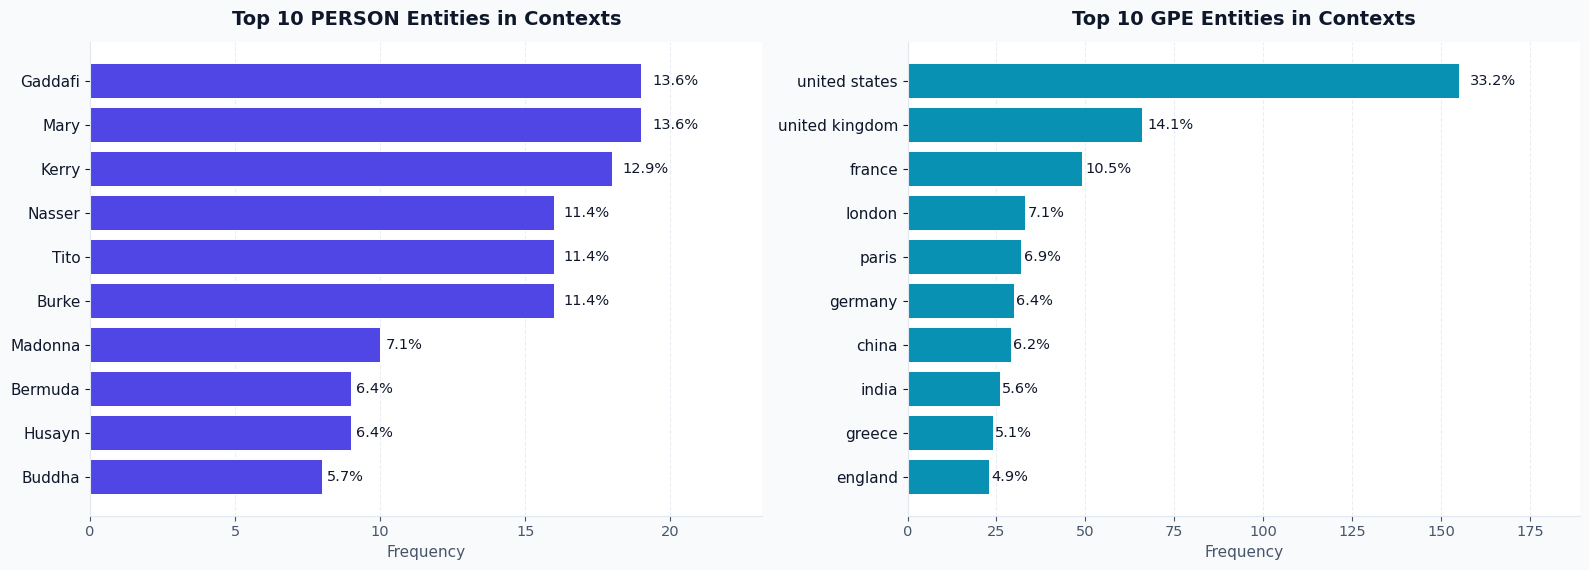

In [680]:
# Top 10 persons and locations in contexts
import re as _re

GPE_ALIASES = {
    'u.s.': 'united states',
    'u.s': 'united states',
    'us': 'united states',
    'usa': 'united states',
    'the united states': 'united states',
    'u.k.': 'united kingdom',
    'uk': 'united kingdom',
    'britain': 'united kingdom'
}

def norm_gpe(s):
    s = str(s).strip().lower()
    s = _re.sub(r'\s+', ' ', s).strip('.,;:()')
    return GPE_ALIASES.get(s, s)

persons = Counter()
gpes = Counter()

for d in docs_c:
    for ent in d.ents:
        if ent.label_ == 'PERSON':
            persons[ent.text.strip()] += 1
        if ent.label_ == 'GPE':
            gpes[norm_gpe(ent.text)] += 1

# ---------- Figure ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 5.8))
fig.patch.set_facecolor('#F8FAFC')

title_color = '#0F172A'
label_color = '#475569'
grid_color  = '#E2E8F0'

# ---------- PERSON ----------
top_p = persons.most_common(10)
labels_p = [k for k, _ in top_p][::-1]
vals_p   = [v for _, v in top_p][::-1]
tot_p    = sum(vals_p)

bars_p = axes[0].barh(
    labels_p,
    vals_p,
    color='#4F46E5',   # indigo
    edgecolor='white',
    linewidth=0.7
)

for bar, v in zip(bars_p, vals_p):
    axes[0].text(
        bar.get_width() + bar.get_width()*0.02,
        bar.get_y() + bar.get_height()/2,
        f'{v/tot_p:.1%}',
        va='center',
        fontsize=10.5,
        color=title_color
    )

axes[0].set_title(
    'Top 10 PERSON Entities in Contexts',
    fontsize=14,
    fontweight='bold',
    color=title_color,
    pad=12
)

axes[0].set_xlabel(
    'Frequency',
    fontsize=11,
    color=label_color
)

axes[0].set_xlim(0, max(vals_p) * 1.22)

# ---------- GPE ----------
top_g = gpes.most_common(10)
labels_g = [k for k, _ in top_g][::-1]
vals_g   = [v for _, v in top_g][::-1]
tot_g    = sum(vals_g)

bars_g = axes[1].barh(
    labels_g,
    vals_g,
    color='#0891B2',   # cyan
    edgecolor='white',
    linewidth=0.7
)

for bar, v in zip(bars_g, vals_g):
    axes[1].text(
        bar.get_width() + bar.get_width()*0.02,
        bar.get_y() + bar.get_height()/2,
        f'{v/tot_g:.1%}',
        va='center',
        fontsize=10.5,
        color=title_color
    )

axes[1].set_title(
    'Top 10 GPE Entities in Contexts',
    fontsize=14,
    fontweight='bold',
    color=title_color,
    pad=12
)

axes[1].set_xlabel(
    'Frequency',
    fontsize=11,
    color=label_color
)

axes[1].set_xlim(0, max(vals_g) * 1.22)

# ---------- Shared styling ----------
for ax in axes:
    ax.set_facecolor('white')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(grid_color)
    ax.spines['bottom'].set_color(grid_color)

    ax.xaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.7, color=grid_color)
    ax.set_axisbelow(True)

    ax.tick_params(axis='x', labelsize=10.5, colors=label_color)
    ax.tick_params(axis='y', labelsize=11, colors=title_color)

plt.tight_layout()
plt.show()

### 5.2 Answer Type Distribution

Running NER on answer texts...


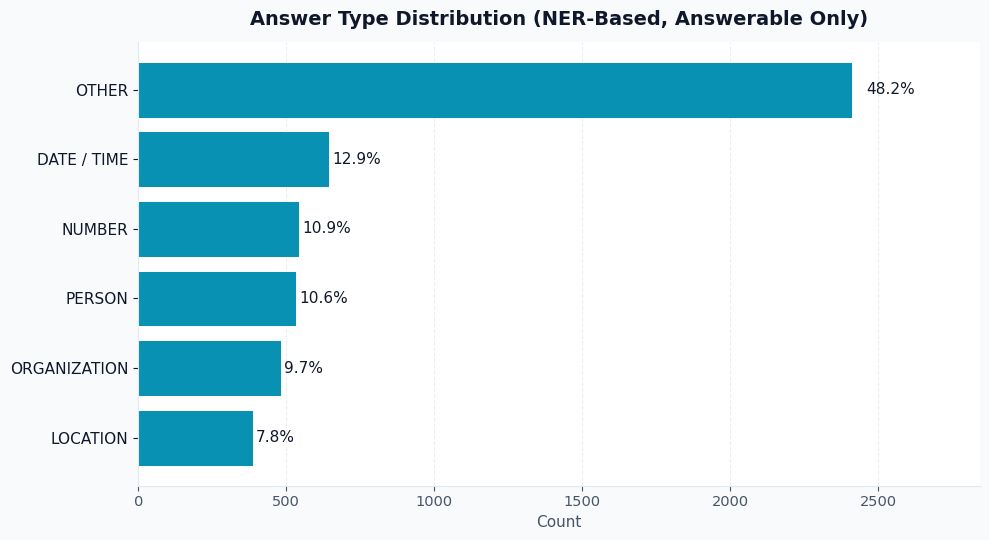

In [681]:
# Categorize answers by NER type using spaCy
# For each answerable question, run NER on the answer text and assign a category

SAMPLE_ANS = 5000
ans_sample = train_df[train_df['y'] == 1]['answer_text'].sample(
    min(SAMPLE_ANS, (train_df['y'] == 1).sum()), random_state=42
).tolist()

print('Running NER on answer texts...')
docs_ans = list(nlp.pipe(ans_sample, batch_size=128))

# Map spaCy NER labels to broader categories
def map_answer_type(doc, text):
    ents = [ent.label_ for ent in doc.ents]
    if 'PERSON' in ents:
        return 'PERSON'
    if 'DATE' in ents or 'TIME' in ents:
        return 'DATE / TIME'
    if 'GPE' in ents or 'LOC' in ents:
        return 'LOCATION'
    if 'CARDINAL' in ents or 'ORDINAL' in ents or 'QUANTITY' in ents:
        return 'NUMBER'
    if 'ORG' in ents:
        return 'ORGANIZATION'
    # fallback: check if numeric
    if text.strip().replace(',', '').replace('.', '').isdigit():
        return 'NUMBER'
    return 'OTHER'

answer_types = [map_answer_type(doc, text) for doc, text in zip(docs_ans, ans_sample)]
type_counts = Counter(answer_types)

# ---------- Data ----------
items   = type_counts.most_common()
labels_t = [k for k, _ in items][::-1]
vals_t   = [v for _, v in items][::-1]
total_t  = sum(vals_t)

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor('#F8FAFC')
ax.set_facecolor('white')

bars = ax.barh(
    labels_t,
    vals_t,
    color='#0891B2',   # cyan
    edgecolor='white',
    linewidth=0.7
)

# Percentage labels
for bar, v in zip(bars, vals_t):
    ax.text(
        bar.get_width() + bar.get_width()*0.02,
        bar.get_y() + bar.get_height()/2,
        f'{v/total_t:.1%}',
        va='center',
        fontsize=11,
        color='#0F172A'
    )

# Titles and labels
ax.set_title(
    'Answer Type Distribution (NER-Based, Answerable Only)',
    fontsize=14,
    fontweight='bold',
    color='#0F172A',
    pad=12
)

ax.set_xlabel(
    'Count',
    fontsize=11,
    color='#475569'
)

ax.set_xlim(0, max(vals_t) * 1.18)

# Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#E2E8F0')
ax.spines['bottom'].set_color('#E2E8F0')

ax.xaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.7, color='#E2E8F0')
ax.set_axisbelow(True)

ax.tick_params(axis='x', labelsize=10.5, colors='#475569')
ax.tick_params(axis='y', labelsize=11, colors='#0F172A')

plt.tight_layout()
plt.show()

### 5.3 Part-of-Speech - PoS Distribution

Part-of-Speech (POS) tagging shows the grammatical composition of questions and contexts. Questions tend to have more pronouns and auxiliary verbs, while contexts have more nouns and proper nouns — reflecting the encyclopedic nature of Wikipedia text.

Running POS tagging...


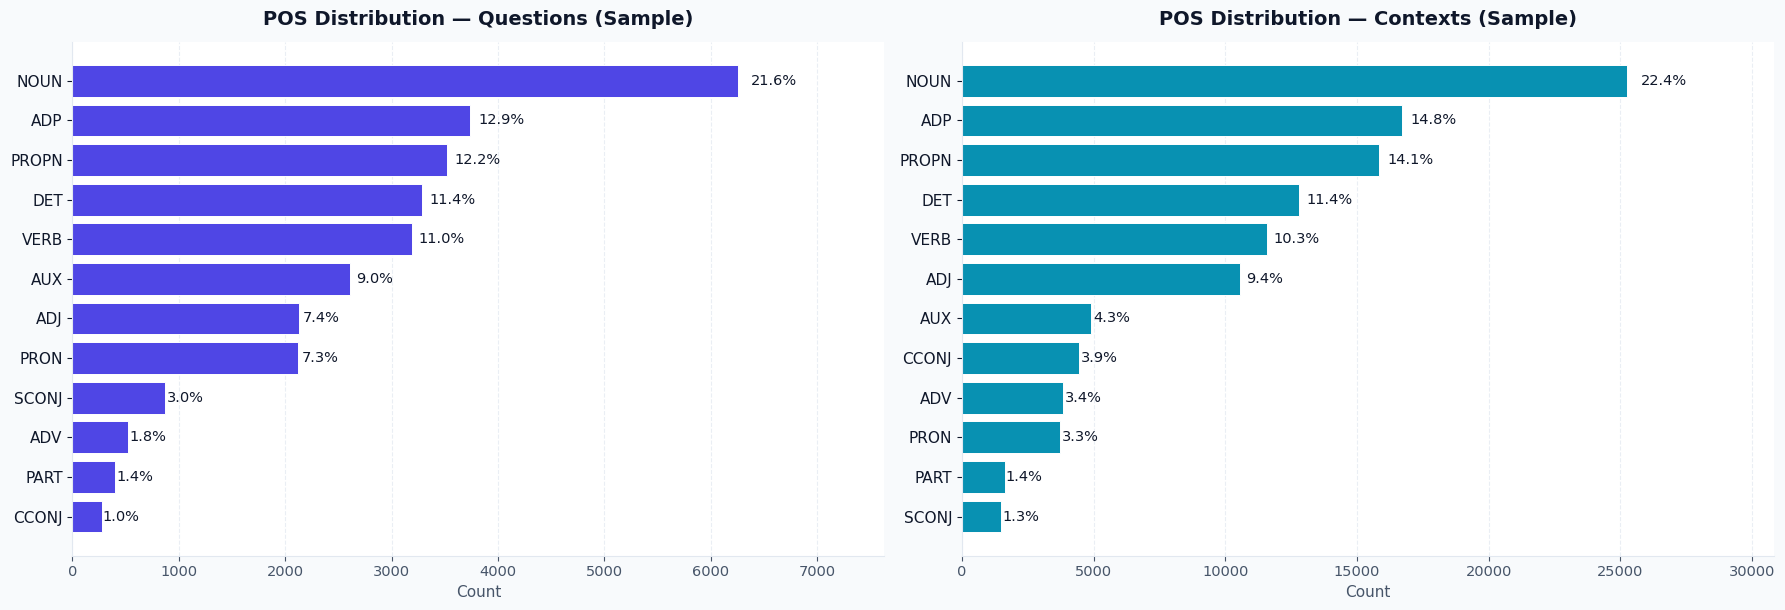

In [688]:
# POS distribution on a sample of questions and contexts
SAMPLE_POS = 3000
sample_pos_q = train_df['question'].sample(
    min(SAMPLE_POS, len(train_df)), random_state=42
).tolist()

sample_pos_c = train_df['context'].drop_duplicates().sample(
    min(1000, train_df['context'].nunique()), random_state=42
).tolist()

print('Running POS tagging...')
docs_pos_q = list(nlp.pipe(sample_pos_q, batch_size=128))
docs_pos_c = list(nlp.pipe(sample_pos_c, batch_size=64))

# Count POS tags — only alphabetic tokens
pos_q = Counter([tok.pos_ for d in docs_pos_q for tok in d if tok.is_alpha])
pos_c = Counter([tok.pos_ for d in docs_pos_c for tok in d if tok.is_alpha])

# ---------- Figure ----------
fig, axes = plt.subplots(1, 2, figsize=(18, 6.2))
fig.patch.set_facecolor('#F8FAFC')

title_color = '#0F172A'
label_color = '#475569'
grid_color  = '#E2E8F0'

for ax, counter, title, color in zip(
    axes,
    [pos_q, pos_c],
    ['POS Distribution — Questions (Sample)', 'POS Distribution — Contexts (Sample)'],
    ['#4F46E5', '#0891B2']   # indigo, cyan
):
    items = counter.most_common(12)
    labels_p = [k for k, _ in items][::-1]
    vals_p   = [v for _, v in items][::-1]
    total_p  = sum(vals_p)

    bars = ax.barh(
        labels_p,
        vals_p,
        color=color,
        edgecolor='white',
        linewidth=0.7
    )

   # Percentage labels (only %)
    for bar, v in zip(bars, vals_p):
        ax.text(
            bar.get_width() + bar.get_width()*0.02,
            bar.get_y() + bar.get_height()/2,
            f'{v/total_p:.1%}',
            va='center',
            fontsize=10.5,
            color=title_color
        )
    

    ax.set_facecolor('white')

    ax.set_title(
        title,
        fontsize=14,
        fontweight='bold',
        color=title_color,
        pad=12
    )

    ax.set_xlabel(
        'Count',
        fontsize=11,
        color=label_color
    )

    ax.set_xlim(0, max(vals_p) * 1.22)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(grid_color)
    ax.spines['bottom'].set_color(grid_color)

    ax.xaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.7, color=grid_color)
    ax.set_axisbelow(True)

    ax.tick_params(axis='x', labelsize=10.5, colors=label_color)
    ax.tick_params(axis='y', labelsize=11, colors=title_color)

plt.tight_layout()
plt.show()

### 5.4 Dependency Parsing

Dependency parsing reveals the grammatical structure of questions. We analyze the distribution of dependency relations (e.g. nsubj = nominal subject, dobj = direct object, ROOT = main verb) to understand how questions are constructed syntactically. We also compare the distribution between answerable and unanswerable questions to see if there are structural differences.

Running dependency parsing on 3000 questions...


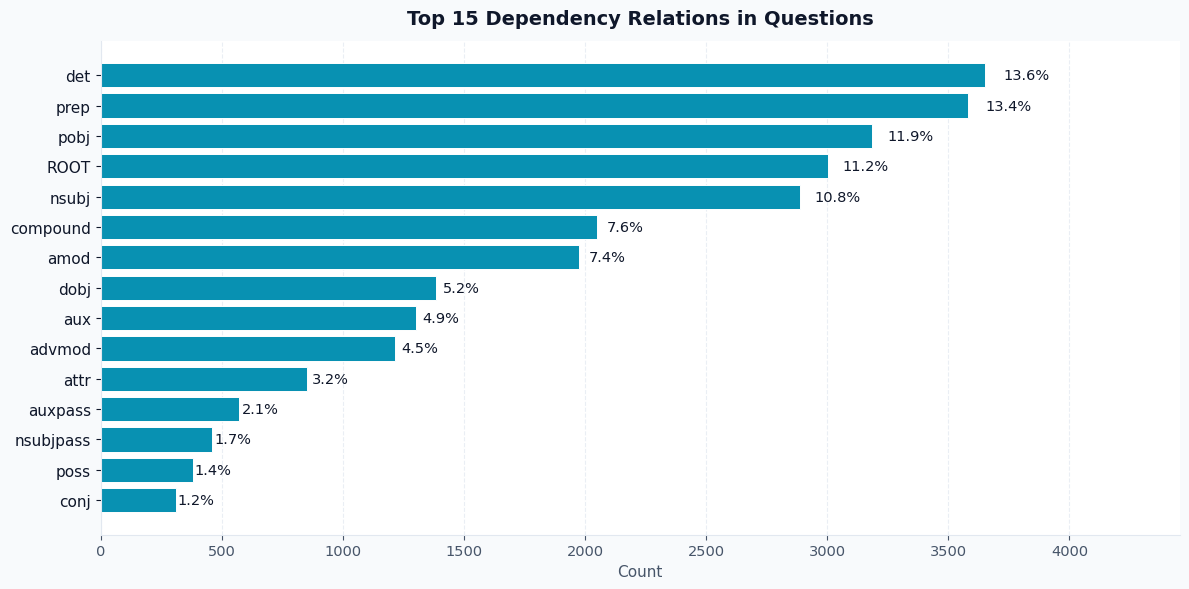

In [689]:
# Parse a sample of questions
SAMPLE_DEP = 3000
sample_q_df = train_df.sample(min(SAMPLE_DEP, len(train_df)), random_state=42).copy()

print(f'Running dependency parsing on {len(sample_q_df)} questions...')
docs_dep = list(nlp.pipe(sample_q_df['question'].tolist(), batch_size=128))
sample_q_df = sample_q_df.reset_index(drop=True)

# Count dependency relations overall
dep_counts = Counter([
    tok.dep_ for doc in docs_dep for tok in doc
    if tok.dep_ != 'punct'
])

top_deps = dep_counts.most_common(15)

labels_d = [k for k, _ in top_deps][::-1]
vals_d   = [v for _, v in top_deps][::-1]
total_d  = sum(vals_d)

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#F8FAFC')
ax.set_facecolor('white')

bars = ax.barh(
    labels_d,
    vals_d,
    color='#0891B2',   # cyan
    edgecolor='white',
    linewidth=0.7
)

# Percentage labels
for bar, v in zip(bars, vals_d):
    ax.text(
        bar.get_width() + bar.get_width()*0.02,
        bar.get_y() + bar.get_height()/2,
        f'{v/total_d:.1%}',
        va='center',
        fontsize=10.5,
        color='#0F172A'
    )

# Titles
ax.set_title(
    'Top 15 Dependency Relations in Questions',
    fontsize=14,
    fontweight='bold',
    color='#0F172A',
    pad=12
)

ax.set_xlabel(
    'Count',
    fontsize=11,
    color='#475569'
)

ax.set_xlim(0, max(vals_d) * 1.22)

# Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#E2E8F0')
ax.spines['bottom'].set_color('#E2E8F0')

ax.xaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.7, color='#E2E8F0')
ax.set_axisbelow(True)

ax.tick_params(axis='x', labelsize=10.5, colors='#475569')
ax.tick_params(axis='y', labelsize=11, colors='#0F172A')

plt.tight_layout()
plt.show()

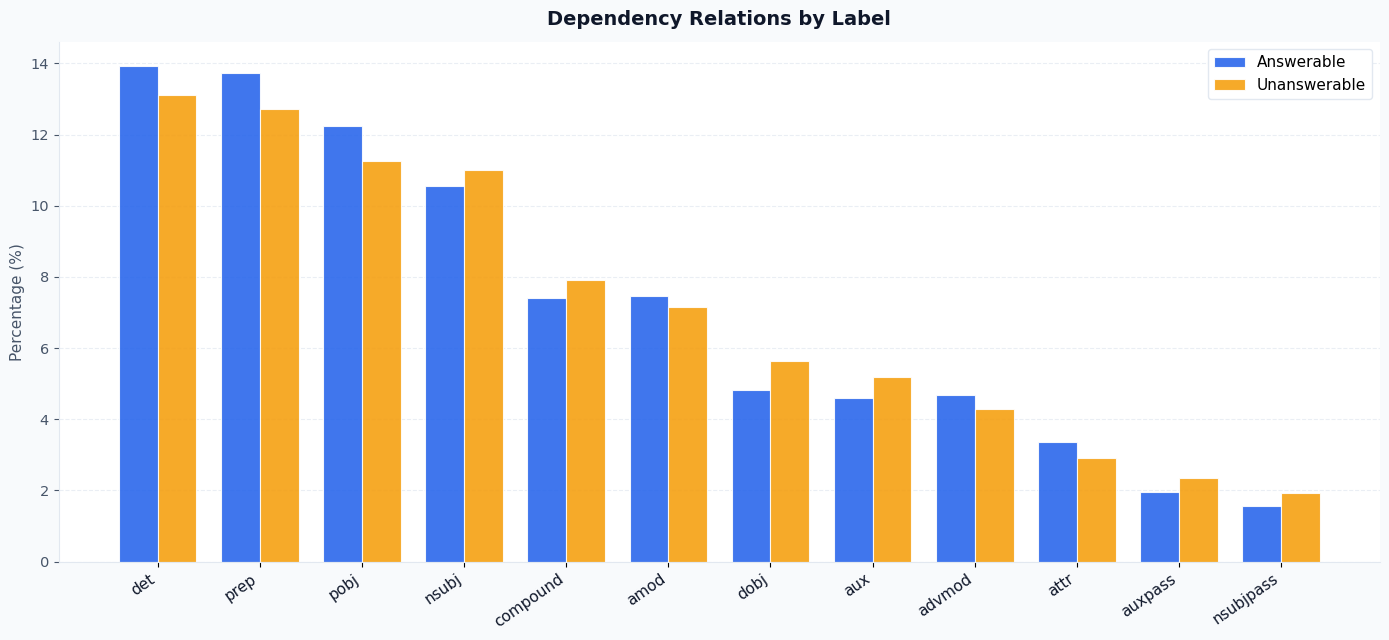

In [710]:
# Separate dependency relations by label to compare syntactic structure
dep_ans   = Counter()
dep_unans = Counter()

for doc, y in zip(docs_dep, sample_q_df['y']):
    # Exclude punctuation and ROOT — focus on meaningful grammatical relations
    deps = [tok.dep_ for tok in doc if tok.dep_ not in ('punct', 'ROOT')]
    if y == 1:
        dep_ans.update(deps)
    else:
        dep_unans.update(deps)

# Normalize counts to percentages for fair comparison between groups
total_ans   = sum(dep_ans.values())
total_unans = sum(dep_unans.values())

# Take union of top-k relations from both groups
top_k = 12
all_deps = list(
    {k for k, _ in dep_ans.most_common(top_k)} |
    {k for k, _ in dep_unans.most_common(top_k)}
)

# Order relations by average percentage across the two groups
all_deps = sorted(
    all_deps,
    key=lambda d: (
        dep_ans.get(d, 0) / total_ans * 100 +
        dep_unans.get(d, 0) / total_unans * 100
    ) / 2,
    reverse=True
)

perc_ans   = [dep_ans.get(d, 0)   / total_ans   * 100 for d in all_deps]
perc_unans = [dep_unans.get(d, 0) / total_unans * 100 for d in all_deps]

x = np.arange(len(all_deps))
width = 0.38

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=(14, 6.5))
fig.patch.set_facecolor('#F8FAFC')
ax.set_facecolor('white')

# Bars
ax.bar(
    x - width/2,
    perc_ans,
    width,
    label='Answerable',
    color='#2563EB',
    alpha=0.88,
    edgecolor='white',
    linewidth=0.8
)

ax.bar(
    x + width/2,
    perc_unans,
    width,
    label='Unanswerable',
    color='#F59E0B',
    alpha=0.88,
    edgecolor='white',
    linewidth=0.8
)

# Axes and labels
ax.set_xticks(x)
ax.set_xticklabels(
    all_deps,
    rotation=35,
    ha='right',
    fontsize=11,
    color='#0F172A'
)

ax.set_title(
    'Dependency Relations by Label',
    fontsize=14,
    fontweight='bold',
    color='#0F172A',
    pad=12
)

ax.set_ylabel(
    'Percentage (%)',
    fontsize=11,
    color='#475569'
)

ax.tick_params(axis='y', labelsize=10.5, colors='#475569')

# Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#E2E8F0')
ax.spines['bottom'].set_color('#E2E8F0')

ax.yaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.7, color='#E2E8F0')
ax.set_axisbelow(True)

ax.legend(
    frameon=True,
    facecolor='white',
    edgecolor='#E2E8F0',
    framealpha=1,
    fontsize=11
)

plt.tight_layout()
plt.show()

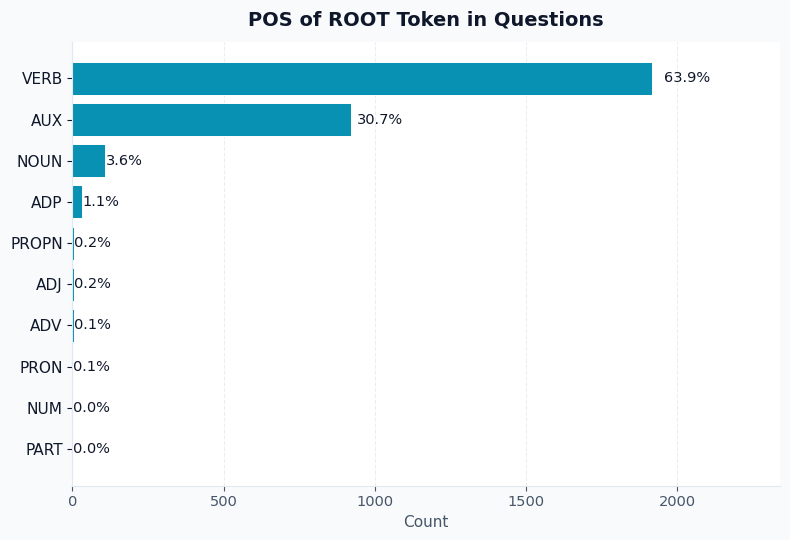

In [714]:
# Count the POS tag of the ROOT token — the main predicate of each question
root_pos = Counter()

for doc in docs_dep:
    for tok in doc:
        if tok.dep_ == 'ROOT':
            root_pos[tok.pos_] += 1

# ---------- Data ----------
items = root_pos.most_common()

labels_r = [k for k, _ in items][::-1]
vals_r   = [v for _, v in items][::-1]
total_r  = sum(vals_r)

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=(8, 5.5))
fig.patch.set_facecolor('#F8FAFC')
ax.set_facecolor('white')

bars = ax.barh(
    labels_r,
    vals_r,
    color='#0891B2',
    edgecolor='white',
    linewidth=0.7
)

# Percentage labels
for bar, v in zip(bars, vals_r):
    ax.text(
        bar.get_width() + bar.get_width()*0.02,
        bar.get_y() + bar.get_height()/2,
        f'{v/total_r:.1%}',
        va='center',
        fontsize=10.5,
        color='#0F172A'
    )

# Titles
ax.set_title(
    'POS of ROOT Token in Questions',
    fontsize=14,
    fontweight='bold',
    color='#0F172A',
    pad=12
)

ax.set_xlabel(
    'Count',
    fontsize=11,
    color='#475569'
)

ax.set_xlim(0, max(vals_r) * 1.22)

# Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#E2E8F0')
ax.spines['bottom'].set_color('#E2E8F0')

ax.xaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.7, color='#E2E8F0')
ax.set_axisbelow(True)

ax.tick_params(axis='x', labelsize=10.5, colors='#475569')
ax.tick_params(axis='y', labelsize=11, colors='#0F172A')

plt.tight_layout()
plt.show()

## 6. Word Clouds by Topic

For the 4 most frequent Wikipedia topics, we generate word clouds using lemmatized tokens with stopwords removed. The size of each word is proportional to its frequency within that topic's questions and contexts.

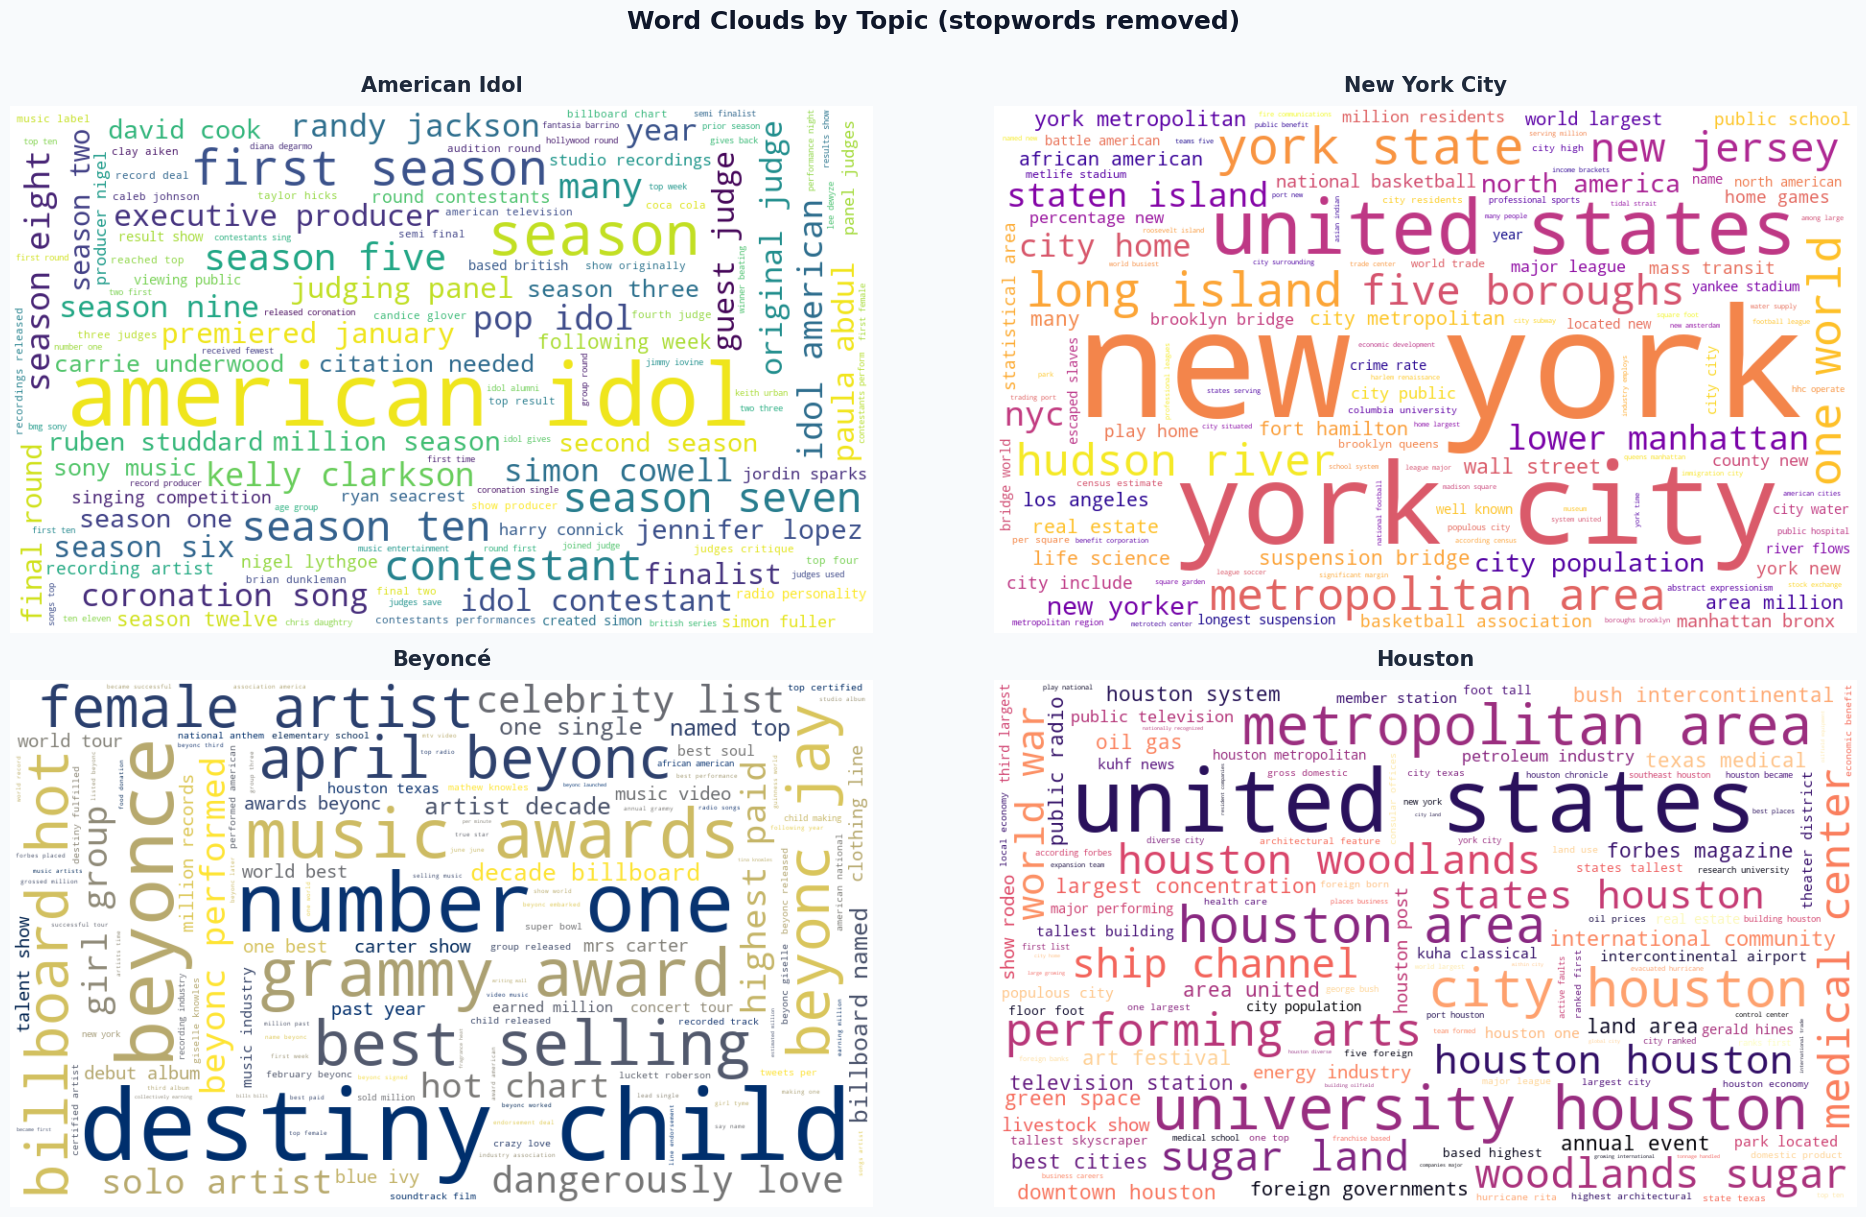

In [715]:
# Select the 4 most frequent topics for the word clouds
top_titles = train_df['title'].value_counts().head(4).index.tolist()
df_wc = train_df[train_df['title'].isin(top_titles)].copy()

# Combine question and context text for richer word representation
df_wc['text'] = df_wc['question'].astype(str) + ' ' + df_wc['context'].astype(str)

# One colormap per topic for visual distinction
CMAPS = ['viridis', 'plasma', 'cividis', 'magma']

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.patch.set_facecolor('#F8FAFC')
axes = axes.flat

for ax, title, cmap in zip(axes, top_titles, CMAPS):
    texts = df_wc.loc[df_wc['title'] == title, 'text'].tolist()

    # Tokenize and filter: lowercase, no stopwords, min 3 characters
    words = []
    for t in texts:
        words += [w.lower() for w in TOKEN_RE.findall(t)
                  if w.lower() not in STOP and len(w) > 2]

    if words:
        # Generate word cloud — word size proportional to frequency
        wc = WordCloud(
            width=900, height=550,
            background_color='white',
            colormap=cmap,
            max_words=120,
            prefer_horizontal=0.85,
            margin=10,
        ).generate(' '.join(words))

        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(title.replace('_', ' '), fontsize=15,
                     fontweight='bold', color='#1E293B', pad=10)

    # Remove axes for cleaner look
    ax.axis('off')
    ax.set_facecolor('#F8FAFC')

fig.suptitle('Word Clouds by Topic (stopwords removed)',
             fontsize=18, fontweight='bold', color='#0F172A', y=1.01)
plt.tight_layout()
plt.show()

## 7. Summary Statistics

A final overview table summarizing the key statistics of the training set.

In [716]:
# Compute key summary statistics for the training set
n_total  = len(train_df)
n_ans    = int(train_df['y'].sum())
n_unans  = n_total - n_ans
n_titles = train_df['title'].nunique()
n_ctx    = train_df['context'].nunique()

# Build summary as a list of (Metric, Value) pairs
summary = [
    ('Total questions',            f'{n_total:,}'),
    ('Answerable (y=1)',           f'{n_ans:,}  ({n_ans/n_total*100:.1f}%)'),
    ('Unanswerable (y=0)',         f'{n_unans:,}  ({n_unans/n_total*100:.1f}%)'),
    ('Unique topics (titles)',     f'{n_titles:,}'),
    ('Unique contexts',            f'{n_ctx:,}'),
    ('Avg question length (tok)',  round(train_df['q_len_tok'].mean(), 1)),
    ('Avg context length (tok)',   round(train_df['c_len_tok'].mean(), 1)),
    ('Avg answer length (tok)',    round(train_df.loc[train_df['y']==1,'a_len_tok'].mean(), 1)),
    ('Avg Q-C overlap',            round(train_df['overlap'].mean(), 3)),
]

# Display as a clean styled table
display(show_table(
    pd.DataFrame(summary, columns=['Metric', 'Value']),
    caption='Training Set Summary',
    n=len(summary)
))

Metric,Value
Total questions,"70,807"
Answerable (y=1),"40,633 (57.4%)"
Unanswerable (y=0),"30,174 (42.6%)"
Unique topics (titles),442
Unique contexts,"13,303"
Avg question length (tok),9.800000
Avg context length (tok),119.300000
Avg answer length (tok),3.100000
Avg Q-C overlap,0.509000
